# OLIST TRUST GAP MODEL


# Delivery Promise Integrity: Predicting Customer Review Scores


# Course: DSAI 4103 — Business Analytics

Dataset: **Olist Brazilian E-Commerce**

Link: **https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce**

## ENVIRONMENT SETUP

In [1]:
!pip install flaml --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 337.7/337.7 kB 5.0 MB/s eta 0:00:00


In [2]:
from google.colab import drive
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import shap
import json
import os
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (f1_score, accuracy_score, matthews_corrcoef,
                              cohen_kappa_score, log_loss, classification_report,
                              confusion_matrix, roc_auc_score, brier_score_loss)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.calibration import calibration_curve
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               ExtraTreesClassifier, AdaBoostClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

from flaml import AutoML

## DATA LOADING

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATA_PATH = '/content/drive/MyDrive/olist_project/'

## DATASET UNDERSTANDING

In [ ]:
orders = pd.read_csv(DATA_PATH + 'olist_orders_dataset.csv')
orders

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00


In [ ]:
reviews  = pd.read_csv(DATA_PATH + 'olist_order_reviews_dataset.csv')
reviews

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
...,...,...,...,...,...,...,...
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07 00:00:00,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09 00:00:00,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01 00:00:00,2018-07-02 12:59:13


In [ ]:
items   = pd.read_csv(DATA_PATH + 'olist_order_items_dataset.csv')
items

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72


In [ ]:
payments = pd.read_csv(DATA_PATH + 'olist_order_payments_dataset.csv')
payments

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45
...,...,...,...,...,...
103881,0406037ad97740d563a178ecc7a2075c,1,boleto,1,363.31
103882,7b905861d7c825891d6347454ea7863f,1,credit_card,2,96.80
103883,32609bbb3dd69b3c066a6860554a77bf,1,credit_card,1,47.77
103884,b8b61059626efa996a60be9bb9320e10,1,credit_card,5,369.54


In [ ]:
customers = pd.read_csv(DATA_PATH + 'olist_customers_dataset.csv')
customers

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP
...,...,...,...,...,...
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS


In [ ]:
products = pd.read_csv(DATA_PATH + 'olist_products_dataset.csv')
products

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0
...,...,...,...,...,...,...,...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao,45.0,67.0,2.0,12300.0,40.0,40.0,40.0
32947,bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao,41.0,971.0,1.0,1700.0,16.0,19.0,16.0
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,50.0,799.0,1.0,1400.0,27.0,7.0,27.0
32949,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios,60.0,156.0,2.0,700.0,31.0,13.0,20.0


In [ ]:
sellers = pd.read_csv(DATA_PATH + 'olist_sellers_dataset.csv')
sellers

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP
...,...,...,...,...
3090,98dddbc4601dd4443ca174359b237166,87111,sarandi,PR
3091,f8201cab383e484733266d1906e2fdfa,88137,palhoca,SC
3092,74871d19219c7d518d0090283e03c137,4650,sao paulo,SP
3093,e603cf3fec55f8697c9059638d6c8eb5,96080,pelotas,RS


In [ ]:
geo = pd.read_csv(DATA_PATH + 'olist_geolocation_dataset.csv')
geo

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP
...,...,...,...,...,...
1000158,99950,-28.068639,-52.010705,tapejara,RS
1000159,99900,-27.877125,-52.224882,getulio vargas,RS
1000160,99950,-28.071855,-52.014716,tapejara,RS
1000161,99980,-28.388932,-51.846871,david canabarro,RS


In [ ]:
translation = pd.read_csv(DATA_PATH + 'product_category_name_translation.csv')
translation

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor
...,...,...
66,flores,flowers
67,artes_e_artesanato,arts_and_craftmanship
68,fraldas_higiene,diapers_and_hygiene
69,fashion_roupa_infanto_juvenil,fashion_childrens_clothes


In [ ]:
tables = {
    'orders'     : orders,
    'reviews'    : reviews,
    'items'      : items,
    'payments'   : payments,
    'customers'  : customers,
    'products'   : products,
    'sellers'    : sellers,
    'geo'        : geo,
    'translation': translation
}

## DataSet Understanding

In [ ]:
# FUNCTION: dataframe Info
def inspect(df, name):
    print(f"  TABLE: {name.upper()}")
    print(f"  Shape: {df.shape[0]:,} rows x {df.shape[1]} columns\n")

    summary = []
    for col in df.columns:
        dtype    = str(df[col].dtype)
        nulls    = df[col].isnull().sum()
        null_pct = (nulls / len(df)) * 100
        unique   = df[col].nunique()
        # sample of up to 3 non-null values
        sample   = df[col].dropna().unique()[:3].tolist()
        summary.append({
            'Column'     : col,
            'Dtype'      : dtype,
            'Nulls'      : nulls,
            'Null %'     : f"{null_pct:.1f}%",
            'Unique vals': unique,
            'Sample'     : str(sample)
        })

    summary_df = pd.DataFrame(summary)
    print(summary_df.to_string(index=False))

In [ ]:
inspect(orders,  'orders')

  TABLE: ORDERS
  Shape: 99,441 rows x 8 columns

                       Column  Dtype  Nulls Null %  Unique vals                                                                                                       Sample
                     order_id object      0   0.0%        99441 ['e481f51cbdc54678b7cc49136f2d6af7', '53cdb2fc8bc7dce0b6741e2150273451', '47770eb9100c2d0c44946d9cf07ec65d']
                  customer_id object      0   0.0%        99441 ['9ef432eb6251297304e76186b10a928d', 'b0830fb4747a6c6d20dea0b8c802d7ef', '41ce2a54c0b03bf3443c3d931a367089']
                 order_status object      0   0.0%            8                                                                         ['delivered', 'invoiced', 'shipped']
     order_purchase_timestamp object      0   0.0%        98875                                        ['2017-10-02 10:56:33', '2018-07-24 20:41:37', '2018-08-08 08:38:49']
            order_approved_at object    160   0.2%        90733                      

In [ ]:
inspect(reviews,  'reviews')

  TABLE: REVIEWS
  Shape: 99,224 rows x 7 columns

                 Column  Dtype  Nulls Null %  Unique vals                                                                                                                                                                                                                                                                                                                              Sample
              review_id object      0   0.0%        98410                                                                                                                                                                                                                        ['7bc2406110b926393aa56f80a40eba40', '80e641a11e56f04c1ad469d5645fdfde', '228ce5500dc1d8e020d8d1322874b6f0']
               order_id object      0   0.0%        98673                                                                                                                                

In [ ]:
inspect(items, 'items')

  TABLE: ITEMS
  Shape: 112,650 rows x 7 columns

             Column   Dtype  Nulls Null %  Unique vals                                                                                                       Sample
           order_id  object      0   0.0%        98666 ['00010242fe8c5a6d1ba2dd792cb16214', '00018f77f2f0320c557190d7a144bdd3', '000229ec398224ef6ca0657da4fc703e']
      order_item_id   int64      0   0.0%           21                                                                                                    [1, 2, 3]
         product_id  object      0   0.0%        32951 ['4244733e06e7ecb4970a6e2683c13e61', 'e5f2d52b802189ee658865ca93d83a8f', 'c777355d18b72b67abbeef9df44fd0fd']
          seller_id  object      0   0.0%         3095 ['48436dade18ac8b2bce089ec2a041202', 'dd7ddc04e1b6c2c614352b383efe2d36', '5b51032eddd242adc84c38acab88f23d']
shipping_limit_date  object      0   0.0%        93318                                        ['2017-09-19 09:45:35', '2017-05-03 

In [ ]:
inspect(payments, 'payments')

  TABLE: PAYMENTS
  Shape: 103,886 rows x 5 columns

              Column   Dtype  Nulls Null %  Unique vals                                                                                                       Sample
            order_id  object      0   0.0%        99440 ['b81ef226f3fe1789b1e8b2acac839d17', 'a9810da82917af2d9aefd1278f1dcfa0', '25e8ea4e93396b6fa0d3dd708e76c1bd']
  payment_sequential   int64      0   0.0%           29                                                                                                    [1, 2, 4]
        payment_type  object      0   0.0%            5                                                                         ['credit_card', 'boleto', 'voucher']
payment_installments   int64      0   0.0%           24                                                                                                    [8, 1, 2]
       payment_value float64      0   0.0%        29077                                                                   

In [ ]:
inspect(customers, 'customers')

  TABLE: CUSTOMERS
  Shape: 99,441 rows x 5 columns

                  Column  Dtype  Nulls Null %  Unique vals                                                                                                       Sample
             customer_id object      0   0.0%        99441 ['06b8999e2fba1a1fbc88172c00ba8bc7', '18955e83d337fd6b2def6b18a428ac77', '4e7b3e00288586ebd08712fdd0374a03']
      customer_unique_id object      0   0.0%        96096 ['861eff4711a542e4b93843c6dd7febb0', '290c77bc529b7ac935b93aa66c333dc3', '060e732b5b29e8181a18229c7b0b2b5e']
customer_zip_code_prefix  int64      0   0.0%        14994                                                                                          [14409, 9790, 1151]
           customer_city object      0   0.0%         4119                                                             ['franca', 'sao bernardo do campo', 'sao paulo']
          customer_state object      0   0.0%           27                                                 

In [ ]:
inspect(products, 'products')

  TABLE: PRODUCTS
  Shape: 32,951 rows x 9 columns

                    Column   Dtype  Nulls Null %  Unique vals                                                                                                       Sample
                product_id  object      0   0.0%        32951 ['1e9e8ef04dbcff4541ed26657ea517e5', '3aa071139cb16b67ca9e5dea641aaa2f', '96bd76ec8810374ed1b65e291975717f']
     product_category_name  object    610   1.9%           73                                                                     ['perfumaria', 'artes', 'esporte_lazer']
       product_name_lenght float64    610   1.9%           66                                                                                           [40.0, 44.0, 46.0]
product_description_lenght float64    610   1.9%         2960                                                                                        [287.0, 276.0, 250.0]
        product_photos_qty float64    610   1.9%           19                                

In [ ]:
inspect(sellers,  'sellers')

  TABLE: SELLERS
  Shape: 3,095 rows x 4 columns

                Column  Dtype  Nulls Null %  Unique vals                                                                                                       Sample
             seller_id object      0   0.0%         3095 ['3442f8959a84dea7ee197c632cb2df15', 'd1b65fc7debc3361ea86b5f14c68d2e2', 'ce3ad9de960102d0677a81f5d0bb7b2d']
seller_zip_code_prefix  int64      0   0.0%         2246                                                                                        [13023, 13844, 20031]
           seller_city object      0   0.0%          611                                                                 ['campinas', 'mogi guacu', 'rio de janeiro']
          seller_state object      0   0.0%           23                                                                                           ['SP', 'RJ', 'PE']


In [ ]:
inspect(geo, 'geo')

  TABLE: GEO
  Shape: 1,000,163 rows x 5 columns

                     Column   Dtype  Nulls Null %  Unique vals                                                       Sample
geolocation_zip_code_prefix   int64      0   0.0%        19015                                           [1037, 1046, 1041]
            geolocation_lat float64      0   0.0%       717360 [-23.54562128115268, -23.54608112703553, -23.54612896641469]
            geolocation_lng float64      0   0.0%       717613 [-46.63929204800168, -46.64482029837157, -46.64295148361138]
           geolocation_city  object      0   0.0%         8011          ['sao paulo', 'são paulo', 'sao bernardo do campo']
          geolocation_state  object      0   0.0%           27                                           ['SP', 'RN', 'AC']


In [ ]:
inspect(translation, 'translation')

  TABLE: TRANSLATION
  Shape: 71 rows x 2 columns

                       Column  Dtype  Nulls Null %  Unique vals                                                   Sample
        product_category_name object      0   0.0%           71 ['beleza_saude', 'informatica_acessorios', 'automotivo']
product_category_name_english object      0   0.0%           71       ['health_beauty', 'computers_accessories', 'auto']


In [ ]:
#  null Check
print("  NULL SUMMARY ACROSS ALL TABLES")
all_tables = {
    'orders': orders, 'reviews': reviews, 'items': items,
    'payments': payments, 'customers': customers,
    'products': products, 'sellers': sellers,
    'geo': geo, 'translation': translation
}
for name, df in all_tables.items():
    total_nulls = df.isnull().sum().sum()
    cols_with_nulls = (df.isnull().sum() > 0).sum()
    print(f"  {name:<15} total nulls: {total_nulls:>8,}   "
          f"columns with nulls: {cols_with_nulls}")

  NULL SUMMARY ACROSS ALL TABLES
  orders          total nulls:    4,908   columns with nulls: 3
  reviews         total nulls:  145,903   columns with nulls: 2
  items           total nulls:        0   columns with nulls: 0
  payments        total nulls:        0   columns with nulls: 0
  customers       total nulls:        0   columns with nulls: 0
  products        total nulls:    2,448   columns with nulls: 8
  sellers         total nulls:        0   columns with nulls: 0
  geo             total nulls:        0   columns with nulls: 0
  translation     total nulls:        0   columns with nulls: 0


## DATA CLEANING & PREPROCESSING

In [ ]:
# Convert all date columns to datetime
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

In [ ]:
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

In [ ]:
for col in date_cols:
    null_count = orders[col].isnull().sum()
    print(f"  {col:<40} {str(orders[col].dtype):<15} nulls: {null_count}")

  order_purchase_timestamp                 datetime64[ns]  nulls: 0
  order_approved_at                        datetime64[ns]  nulls: 160
  order_delivered_carrier_date             datetime64[ns]  nulls: 1783
  order_delivered_customer_date            datetime64[ns]  nulls: 2965
  order_estimated_delivery_date            datetime64[ns]  nulls: 0


In [ ]:
# 5th paymentType
payment_counts = payments['payment_type'].value_counts()
print(payment_counts.to_string())
print(f"\nTotal payment rows: {len(payments):,}")

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3

Total payment rows: 103,886


In [ ]:
# Check order_status values
status_counts = orders['order_status'].value_counts()
for status, count in status_counts.items():
    pct = (count / len(orders)) * 100
    print(f"  {status:<25} {count:>7,}   ({pct:.1f}%)")

  delivered                  96,478   (97.0%)
  shipped                     1,107   (1.1%)
  canceled                      625   (0.6%)
  unavailable                   609   (0.6%)
  invoiced                      314   (0.3%)
  processing                    301   (0.3%)
  created                         5   (0.0%)
  approved                        2   (0.0%)


In [ ]:
# delivered orders
orders_delivered = orders[orders['order_status'] == 'delivered'].copy()
print(f"  Before filter:  {len(orders):>7,} orders")
print(f"  After filter:   {len(orders_delivered):>7,} orders")
print(f"  Rows removed:   {len(orders) - len(orders_delivered):>7,} orders")
print(f"  % kept:         {len(orders_delivered)/len(orders)*100:.1f}%")

  Before filter:   99,441 orders
  After filter:    96,478 orders
  Rows removed:     2,963 orders
  % kept:         97.0%


In [ ]:
# After filtering Nulls left
for col in date_cols:
    nulls = orders_delivered[col].isnull().sum()
    pct   = (nulls / len(orders_delivered)) * 100
    print(f"  {col:<40} {nulls:>6,}  ({pct:.2f}%)")

  order_purchase_timestamp                      0  (0.00%)
  order_approved_at                            14  (0.01%)
  order_delivered_carrier_date                  2  (0.00%)
  order_delivered_customer_date                 8  (0.01%)
  order_estimated_delivery_date                 0  (0.00%)


## FEATURE ENGINEERING

In [ ]:
# Date Rasnge
print(f"  Earliest order: {orders_delivered['order_purchase_timestamp'].min()}")
print(f"  Latest order:   {orders_delivered['order_purchase_timestamp'].max()}")
print(f"  Earliest delivery: {orders_delivered['order_delivered_customer_date'].min()}")
print(f"  Latest delivery:   {orders_delivered['order_delivered_customer_date'].max()}")

  Earliest order: 2016-09-15 12:16:38
  Latest order:   2018-08-29 15:00:37
  Earliest delivery: 2016-10-11 13:46:32
  Latest delivery:   2018-10-17 13:22:46


In [ ]:
before = len(orders_delivered)
orders_clean = orders_delivered.dropna(subset=[
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'order_approved_at'
]).copy()
after = len(orders_clean)

print(f"Rows after dropping remaining nulls: {after:,}")
print(f"Rows dropped: {before - after}")

Rows after dropping remaining nulls: 96,456
Rows dropped: 22


In [ ]:
orders_clean['trust_gap_days'] = (
    orders_clean['order_delivered_customer_date'] -
    orders_clean['order_estimated_delivery_date']
).dt.days

orders_clean['approval_lag_days'] = (
    orders_clean['order_approved_at'] -
    orders_clean['order_purchase_timestamp']
).dt.days

orders_clean['shipping_lag_days'] = (
    orders_clean['order_delivered_carrier_date'] -
    orders_clean['order_approved_at']
).dt.days

orders_clean['actual_delivery_days'] = (
    orders_clean['order_delivered_customer_date'] -
    orders_clean['order_purchase_timestamp']
).dt.days

orders_clean['promised_delivery_days'] = (
    orders_clean['order_estimated_delivery_date'] -
    orders_clean['order_purchase_timestamp']
).dt.days

In [ ]:
new_cols = [
    'trust_gap_days', 'approval_lag_days',
    'shipping_lag_days', 'actual_delivery_days',
    'promised_delivery_days'
]
print(orders_clean[new_cols].describe().round(2).to_string())

       trust_gap_days  approval_lag_days  shipping_lag_days  actual_delivery_days  promised_delivery_days
count        96456.00           96456.00           96455.00              96456.00                96456.00
mean           -11.87               0.26               2.30                 12.09                   23.37
std             10.18               0.73               3.55                  9.55                    8.76
min           -147.00               0.00            -172.00                  0.00                    2.00
25%            -17.00               0.00               0.00                  6.00                   18.00
50%            -12.00               0.00               1.00                 10.00                   23.00
75%             -7.00               0.00               3.00                 15.00                   28.00
max            188.00              30.00             125.00                209.00                  155.00


In [ ]:
early   = (orders_clean['trust_gap_days'] < 0).sum()
on_time = (orders_clean['trust_gap_days'] == 0).sum()
late_1  = ((orders_clean['trust_gap_days'] > 0) &
           (orders_clean['trust_gap_days'] <= 7)).sum()
late_2  = ((orders_clean['trust_gap_days'] > 7) &
           (orders_clean['trust_gap_days'] <= 14)).sum()
late_3  = (orders_clean['trust_gap_days'] > 14).sum()
total   = len(orders_clean)

In [ ]:
print(f"  Arrived EARLY (gap < 0):          "
      f"{early:>7,}  ({early/total*100:.1f}%)")
print(f"  Arrived ON TIME (gap = 0):        "
      f"{on_time:>7,}  ({on_time/total*100:.1f}%)")
print(f"  Late 1-7 days:                    "
      f"{late_1:>7,}  ({late_1/total*100:.1f}%)")
print(f"  Late 8-14 days:                   "
      f"{late_2:>7,}  ({late_2/total*100:.1f}%)")
print(f"  Late 15+ days:                    "
      f"{late_3:>7,}  ({late_3/total*100:.1f}%)")
print(f"\n  Total orders analyzed:            {total:>7,}")

  Arrived EARLY (gap < 0):           88,630  (91.9%)
  Arrived ON TIME (gap = 0):          1,292  (1.3%)
  Late 1-7 days:                      3,672  (3.8%)
  Late 8-14 days:                     1,478  (1.5%)
  Late 15+ days:                      1,384  (1.4%)

  Total orders analyzed:             96,456


## BUILD MASTER DATASET

In [ ]:
reviews_clean = reviews[['order_id', 'review_score']].dropna()
merged = orders_clean.merge(reviews_clean, on='order_id', how='inner')

In [ ]:
print(f"  Orders with reviews after merge: {len(merged):,}")

  Orders with reviews after merge: 96,339


In [ ]:
bins   = [-999, -1, 0, 3, 7, 14, 21, 999]
labels = ['Early', 'On time', '1-3 days late', '4-7 days late',
          '8-14 days late', '15-21 days late', '21+ days late']
merged['delay_bucket'] = pd.cut(
    merged['trust_gap_days'], bins=bins, labels=labels
)

In [ ]:
summary = merged.groupby('delay_bucket', observed=True).agg(
    orders      = ('order_id', 'count'),
    avg_score   = ('review_score', 'mean'),
    pct_1star   = ('review_score', lambda x: (x == 1).sum() / len(x) * 100),
    pct_5star   = ('review_score', lambda x: (x == 5).sum() / len(x) * 100)
).round(2)

In [ ]:
print(summary.to_string())

                 orders  avg_score  pct_1star  pct_5star
delay_bucket                                            
Early             88639       4.29       6.60      62.43
On time            1291       4.03       8.52      50.43
1-3 days late      1856       3.29      25.16      33.14
4-7 days late      1756       2.10      58.54      14.12
8-14 days late     1452       1.68      70.39       6.96
15-21 days late     652       1.67      68.56       5.98
21+ days late       693       1.78      69.26       8.23


In [ ]:
items_agg = items.groupby('order_id').agg(
    total_price      = ('price',         'sum'),
    total_freight    = ('freight_value', 'sum'),
    item_count       = ('order_item_id', 'max'),  # max item_id = item count
    product_id       = ('product_id',    'first'), # first product for category
    seller_id        = ('seller_id',     'first')  # first seller
).reset_index()

In [ ]:
print(f"items_agg shape: {items_agg.shape}")
print(f"Sample:\n{items_agg.head(3).to_string()}\n")

items_agg shape: (98666, 6)
Sample:
                           order_id  total_price  total_freight  item_count                        product_id                         seller_id
0  00010242fe8c5a6d1ba2dd792cb16214         58.9          13.29           1  4244733e06e7ecb4970a6e2683c13e61  48436dade18ac8b2bce089ec2a041202
1  00018f77f2f0320c557190d7a144bdd3        239.9          19.93           1  e5f2d52b802189ee658865ca93d83a8f  dd7ddc04e1b6c2c614352b383efe2d36
2  000229ec398224ef6ca0657da4fc703e        199.0          17.87           1  c777355d18b72b67abbeef9df44fd0fd  5b51032eddd242adc84c38acab88f23d



In [ ]:
payments_clean = payments[payments['payment_type'] != 'not_defined']

payments_agg = payments_clean.groupby('order_id').agg(
    payment_type         = ('payment_type',         'first'),
    payment_installments = ('payment_installments', 'max'),
    payment_value        = ('payment_value',        'sum')
).reset_index()

print(f"payments_agg shape: {payments_agg.shape}")

payments_agg shape: (99437, 4)


In [ ]:
geo_dedup = geo.groupby('geolocation_zip_code_prefix').agg(
    lat   = ('geolocation_lat', 'mean'),
    lng   = ('geolocation_lng', 'mean'),
    state = ('geolocation_state', 'first')
).reset_index()

print(f"geo_dedup shape: {geo_dedup.shape} (was 1,000,163)")

geo_dedup shape: (19015, 4) (was 1,000,163)


In [ ]:
master = orders_clean.copy()

In [ ]:
master

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,trust_gap_days,approval_lag_days,shipping_lag_days,actual_delivery_days,promised_delivery_days
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,-8,0,2.0,8,15
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,-6,1,0.0,13,19
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,-18,0,0.0,9,26
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,-13,0,3.0,13,26
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,-10,0,0.0,2,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,-11,0,1.0,8,18
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,-2,0,1.0,22,23
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,-6,0,1.0,24,30
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,-21,0,3.0,17,37


In [ ]:
master = master.merge(
    reviews[['order_id', 'review_score']],
    on='order_id', how='left'
)

In [ ]:
print(f"\nAfter joining reviews:   {master.shape}")


After joining reviews:   (96985, 14)


In [ ]:
master = master.merge(items_agg, on='order_id', how='left')

In [ ]:
print(f"After joining items:     {master.shape}")

After joining items:     (96985, 19)


In [ ]:
master = master.merge(payments_agg, on='order_id', how='left')

In [ ]:
print(f"After joining payments:  {master.shape}")

After joining payments:  (96985, 22)


In [ ]:
master = master.merge(
    customers[['customer_id', 'customer_state',
               'customer_zip_code_prefix']],
    on='customer_id', how='left'
)

In [ ]:
print(f"After joining customers: {master.shape}")

After joining customers: (96985, 24)


In [ ]:
master = master.merge(
    products[['product_id', 'product_category_name',
              'product_weight_g', 'product_length_cm',
              'product_height_cm', 'product_width_cm']],
    on='product_id', how='left'
)

In [ ]:
print(f"After joining products:  {master.shape}")

After joining products:  (96985, 29)


In [ ]:
master = master.merge(
    sellers[['seller_id', 'seller_state']],
    on='seller_id', how='left'
)

In [ ]:
print(f"After joining sellers:   {master.shape}")

After joining sellers:   (96985, 30)


In [ ]:
master = master.merge(
    translation,
    on='product_category_name', how='left'
)

In [ ]:
master['product_category_name_english'] = (
    master['product_category_name_english']
    .fillna(master['product_category_name'])
    .fillna('unknown')
)

In [ ]:
print(f"After joining translation: {master.shape}")

After joining translation: (96985, 31)


In [ ]:
print("Columns in master DataFrame:")
print(master.columns.tolist())
print(f"\n'seller_state' exists in master: {'seller_state' in master.columns}")

Columns in master DataFrame:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'trust_gap_days', 'approval_lag_days', 'shipping_lag_days', 'actual_delivery_days', 'promised_delivery_days', 'review_score', 'total_price', 'total_freight', 'item_count', 'product_id', 'seller_id', 'payment_type', 'payment_installments', 'payment_value', 'customer_state', 'customer_zip_code_prefix', 'product_category_name', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'seller_state', 'product_category_name_english']

'seller_state' exists in master: True


In [ ]:
master['freight_ratio'] = (
    master['total_freight'] /
    (master['total_price'] + 0.01)  # +0.01 avoids division by zero
).round(4)

In [ ]:
master['same_state'] = (
    master['seller_state'] == master['customer_state']
).astype(int)

In [ ]:
master['order_value_total'] = (
    master['total_price'] + master['total_freight']
)

In [ ]:
master['product_volume_cm3'] = (
    master['product_length_cm'] *
    master['product_height_cm'] *
    master['product_width_cm']
)

In [ ]:
master['high_installments'] = (
    master['payment_installments'] >= 6
).astype(int)

In [ ]:
master['is_credit_card'] = (
    master['payment_type'] == 'credit_card'
).astype(int)

In [ ]:
print(f"\nFinal master dataset shape: {master.shape}")


Final master dataset shape: (96985, 37)


In [ ]:
print(f"\nNULLS IN MASTER DATASET:")
null_counts = master.isnull().sum()
null_counts = null_counts[null_counts > 0].sort_values(ascending=False)
for col, count in null_counts.items():
    pct = count / len(master) * 100
    print(f"  {col:<40} {count:>6,}  ({pct:.2f}%)")

if len(null_counts) == 0:
    print("  No nulls found! perfectly clean!")


NULLS IN MASTER DATASET:
  product_category_name                     1,366  (1.41%)
  review_score                                646  (0.67%)
  product_weight_g                             16  (0.02%)
  product_height_cm                            16  (0.02%)
  product_width_cm                             16  (0.02%)
  product_volume_cm3                           16  (0.02%)
  product_length_cm                            16  (0.02%)
  order_delivered_carrier_date                  1  (0.00%)
  payment_type                                  1  (0.00%)
  shipping_lag_days                             1  (0.00%)
  payment_installments                          1  (0.00%)
  payment_value                                 1  (0.00%)


In [ ]:
print(f"\nFINAL COLUMNS IN MASTER DATASET ({len(master.columns)} total):")
for i, col in enumerate(master.columns, 1):
    print(f"  {i:>2}. {col}")

print(f"\nMaster dataset ready: {master.shape}")


FINAL COLUMNS IN MASTER DATASET (37 total):
   1. order_id
   2. customer_id
   3. order_status
   4. order_purchase_timestamp
   5. order_approved_at
   6. order_delivered_carrier_date
   7. order_delivered_customer_date
   8. order_estimated_delivery_date
   9. trust_gap_days
  10. approval_lag_days
  11. shipping_lag_days
  12. actual_delivery_days
  13. promised_delivery_days
  14. review_score
  15. total_price
  16. total_freight
  17. item_count
  18. product_id
  19. seller_id
  20. payment_type
  21. payment_installments
  22. payment_value
  23. customer_state
  24. customer_zip_code_prefix
  25. product_category_name
  26. product_weight_g
  27. product_length_cm
  28. product_height_cm
  29. product_width_cm
  30. seller_state
  31. product_category_name_english
  32. freight_ratio
  33. same_state
  34. order_value_total
  35. product_volume_cm3
  36. high_installments
  37. is_credit_card

Master dataset ready: (96985, 37)


In [ ]:
before = len(master)
master = master.sort_values('order_id').drop_duplicates(
    subset='order_id', keep='first'
).reset_index(drop=True)
after = len(master)

print(f"DEDUPLICATION:")
print(f"  Before: {before:,} rows")
print(f"  After:  {after:,} rows")
print(f"  Removed: {before - after} duplicate rows")

DEDUPLICATION:
  Before: 96,985 rows
  After:  96,456 rows
  Removed: 529 duplicate rows


In [ ]:
before = len(master)
master = master.dropna(subset=['review_score']).copy()
after = len(master)

print(f"\nDROP NULL TARGETS (review_score):")
print(f"  Before: {before:,} rows")
print(f"  After:  {after:,} rows")
print(f"  Removed: {before - after} rows with no review")


DROP NULL TARGETS (review_score):
  Before: 96,456 rows
  After:  95,810 rows
  Removed: 646 rows with no review


In [ ]:
dim_cols = ['product_weight_g', 'product_length_cm',
            'product_height_cm', 'product_width_cm']

for col in dim_cols:
    median_val = master[col].median()
    null_count = master[col].isnull().sum()
    master[col] = master[col].fillna(median_val)
    print(f"  Imputed {null_count} nulls in {col} with median {median_val:.1f}")

# Recalculate product_volume_cm3 after imputation
master['product_volume_cm3'] = (
    master['product_length_cm'] *
    master['product_height_cm'] *
    master['product_width_cm']
)

  Imputed 16 nulls in product_weight_g with median 700.0
  Imputed 16 nulls in product_length_cm with median 25.0
  Imputed 16 nulls in product_height_cm with median 13.0
  Imputed 16 nulls in product_width_cm with median 20.0


In [ ]:
master['product_category_name'] = (
    master['product_category_name'].fillna('unknown')
)
master['product_category_name_english'] = (
    master['product_category_name_english'].fillna('unknown')
)

In [ ]:
before = len(master)
master = master.dropna(subset=[
    'payment_type', 'payment_installments',
    'payment_value', 'shipping_lag_days'
]).copy()
after = len(master)
print(f"\nDropped {before - after} rows with single-field nulls")


Dropped 2 rows with single-field nulls


In [ ]:
p1  = master['trust_gap_days'].quantile(0.01)
p99 = master['trust_gap_days'].quantile(0.99)
master['trust_gap_days'] = master['trust_gap_days'].clip(p1, p99)
print(f"OUTLIER CAPPING:")
print(f"  trust_gap_days capped to [{p1:.0f}, {p99:.0f}]")

OUTLIER CAPPING:
  trust_gap_days capped to [-36, 18]


In [ ]:
neg_ship = (master['shipping_lag_days'] < 0).sum()
master['shipping_lag_days'] = master['shipping_lag_days'].clip(lower=0)
print(f"  shipping_lag_days: fixed {neg_ship} negative values → 0")

  shipping_lag_days: fixed 1343 negative values → 0


In [ ]:
p99_del = master['actual_delivery_days'].quantile(0.99)
master['actual_delivery_days'] = master['actual_delivery_days'].clip(
    upper=p99_del
)
print(f"  actual_delivery_days capped at 99th percentile: {p99_del:.0f} days")

  actual_delivery_days capped at 99th percentile: 45 days


In [ ]:
master['review_score'] = master['review_score'].astype(int)

In [ ]:
print(f"\nFINAL NULL CHECK:")
remaining_nulls = master.isnull().sum().sum()
if remaining_nulls == 0:
    print(f"  PASSED — zero nulls in dataset")
else:
    print(f"  WARNING — {remaining_nulls} nulls remain:")
    print(master.isnull().sum()[master.isnull().sum() > 0])


FINAL NULL CHECK:
  PASSED — zero nulls in dataset


In [ ]:
print(f"\nFINAL CLEAN DATASET:")
print(f"  Shape: {master.shape[0]:,} rows × {master.shape[1]} columns")
print(f"\nREVIEW SCORE DISTRIBUTION (our target):")
print("-" * 45)
score_dist = master['review_score'].value_counts().sort_index()
for score, count in score_dist.items():
    pct = count / len(master) * 100
    bar = '|' * int(pct / 2)
    print(f"  {score} star:  {count:>7,}  ({pct:>5.1f}%)  {bar}")


FINAL CLEAN DATASET:
  Shape: 95,808 rows × 37 columns

REVIEW SCORE DISTRIBUTION (our target):
---------------------------------------------
  1 star:    9,347  (  9.8%)  ||||
  2 star:    2,924  (  3.1%)  |
  3 star:    7,900  (  8.2%)  ||||
  4 star:   18,884  ( 19.7%)  |||||||||
  5 star:   56,753  ( 59.2%)  |||||||||||||||||||||||||||||


In [ ]:
master.columns = master.columns.astype(str)
master.to_csv(DATA_PATH + 'master_clean.csv', index=False)
print(f"\nSaved: master_clean.csv → {DATA_PATH}")


Saved: master_clean.csv → /content/drive/MyDrive/olist_project/


In [ ]:
try:
    _ = master_clean.shape
    print(f"master_clean already in memory: {master_clean.shape}")
except NameError:
    master_clean = pd.read_csv(
        '/content/drive/MyDrive/olist_project/master_clean.csv'
    )
    print(f"Loaded master_clean from CSV: {master_clean.shape}")

    plt.rcParams.update({
    'figure.facecolor'  : '#FAFAFA',
    'axes.facecolor'    : '#FAFAFA',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.titlesize'    : 14,
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 11,
    'xtick.labelsize'   : 10,
    'ytick.labelsize'   : 10,
    'font.family'       : 'DejaVu Sans'
})

SAVE_PATH = '/content/drive/MyDrive/olist_project/eda_plots/'
import os
os.makedirs(SAVE_PATH, exist_ok=True)

PALETTE_DIV  = ['#1F4E79', '#2E75B6', '#A9C4E0', '#F4B942', '#C0392B']
SCORE_COLORS = {1: '#C0392B', 2: '#E67E22', 3: '#F4B942', 4: '#2980B9', 5: '#1F4E79'}

print(f"Working with {len(master_clean):,} orders across {master_clean['customer_state'].nunique()} states.\n")


Loaded master_clean from CSV: (95808, 37)
Working with 95,808 orders across 27 states.



## EXPLORATORY DATA ANALYSIS

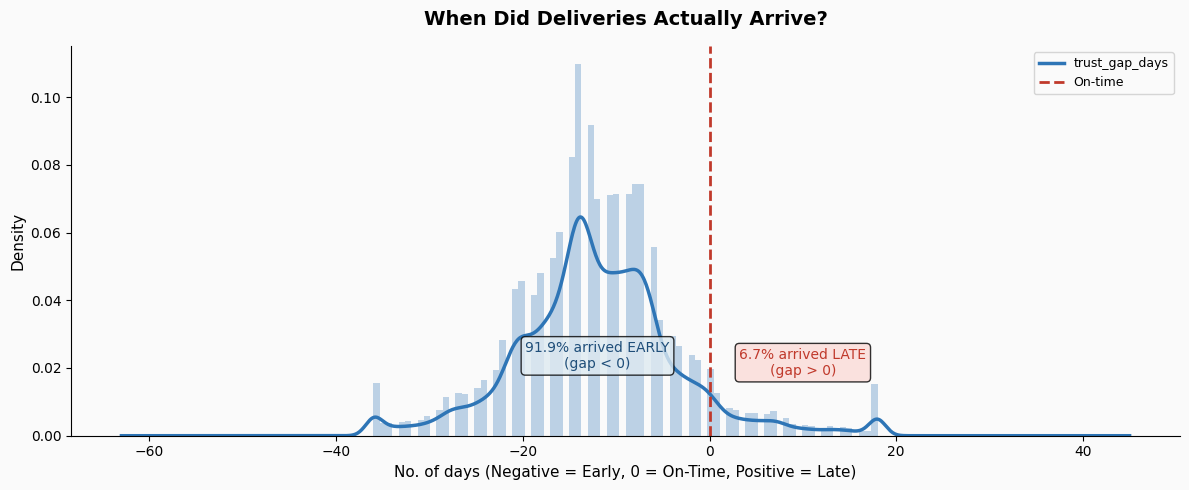

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

# Plot KDE (smoothed curve)
master_clean['trust_gap_days'].plot.kde(
    ax=ax, color='#2E75B6', linewidth=2.5
)

# Overlay a histogram (normalized to match KDE scale)
ax.hist(
    master_clean['trust_gap_days'],
    bins=80,
    density=True,           # normalize so it matches KDE y-axis
    alpha=0.3,
    color='#2E75B6'
)

# Add vertical lines at key thresholds
ax.axvline(0, color='#C0392B', linestyle='--', linewidth=2,
           label='On-time')

ax.set_title('When Did Deliveries Actually Arrive?', pad=15)
ax.set_xlabel('No. of days (Negative = Early, 0 = On-Time, Positive = Late)')
ax.legend(loc='upper right', fontsize=9)

# Annotate the two regions

ax.annotate('91.9% arrived EARLY\n(gap < 0)',
            xy=(-12, 0.02), fontsize=10, color='#1F4E79',
            ha='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#DEEAF1', alpha=0.8))
ax.annotate('6.7% arrived LATE\n(gap > 0)',
            xy=(10, 0.018), fontsize=10, color='#C0392B',
            ha='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#FADBD8', alpha=0.8))

plt.tight_layout()
plt.savefig(SAVE_PATH + 'plot1_trust_gap_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
skewness = master_clean['trust_gap_days'].skew()
kurtosis = master_clean['trust_gap_days'].kurtosis()
print("PLOT 1 — TRUST GAP STATISTICS:")
print(f"  Mean:     {master_clean['trust_gap_days'].mean():.2f} days")
print(f"  Median:   {master_clean['trust_gap_days'].median():.2f} days")
print(f"  Std Dev:  {master_clean['trust_gap_days'].std():.2f} days")
print(f"  Skewness: {skewness:.3f}  (positive = right tail, i.e. some very late orders)")
print(f"  Kurtosis: {kurtosis:.3f}  (positive = heavier tails than normal distribution)")
print()

PLOT 1 — TRUST GAP STATISTICS:
  Mean:     -12.00 days
  Median:   -12.00 days
  Std Dev:  8.88 days
  Skewness: 0.361  (positive = right tail, i.e. some very late orders)
  Kurtosis: 1.475  (positive = heavier tails than normal distribution)



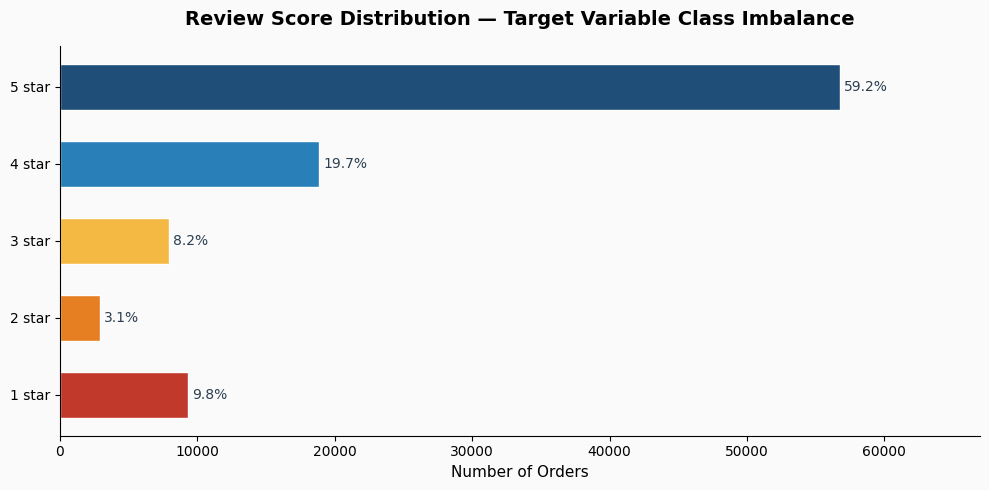

REVIEW SCORE COUNTS:
  1star   9,347  (  9.8%)  |||||||||
  2star   2,924  (  3.1%)  |||
  3star   7,900  (  8.2%)  ||||||||
  4star  18,884  ( 19.7%)  |||||||||||||||||||
  5star  56,753  ( 59.2%)  |||||||||||||||||||||||||||||||||||||||||||||||||||||||||||



In [ ]:
score_counts = master_clean['review_score'].value_counts().sort_index()
score_pct    = (score_counts / len(master_clean) * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(
    [f'{s} star' for s in score_counts.index],
    score_counts.values,
    color=[SCORE_COLORS[s] for s in score_counts.index],
    height=0.6,
    edgecolor='white'
)

for bar, count, pct in zip(bars, score_counts.values, score_pct.values):
    ax.text(bar.get_width() + 300, bar.get_y() + bar.get_height()/2,
            f'{pct}%',
            va='center', ha='left', fontsize=10, color='#2C3E50')

ax.set_title('Review Score Distribution — Target Variable Class Imbalance', pad=15)
ax.set_xlabel('Number of Orders')
ax.set_xlim(0, score_counts.max() * 1.18)

plt.tight_layout()
plt.savefig(SAVE_PATH + 'review_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("REVIEW SCORE COUNTS:")
for score, count, pct in zip(score_counts.index, score_counts.values, score_pct.values):
    bar = '|' * int(pct)
    print(f"  {score}star  {count:>6,}  ({pct:>5.1f}%)  {bar}")
print()


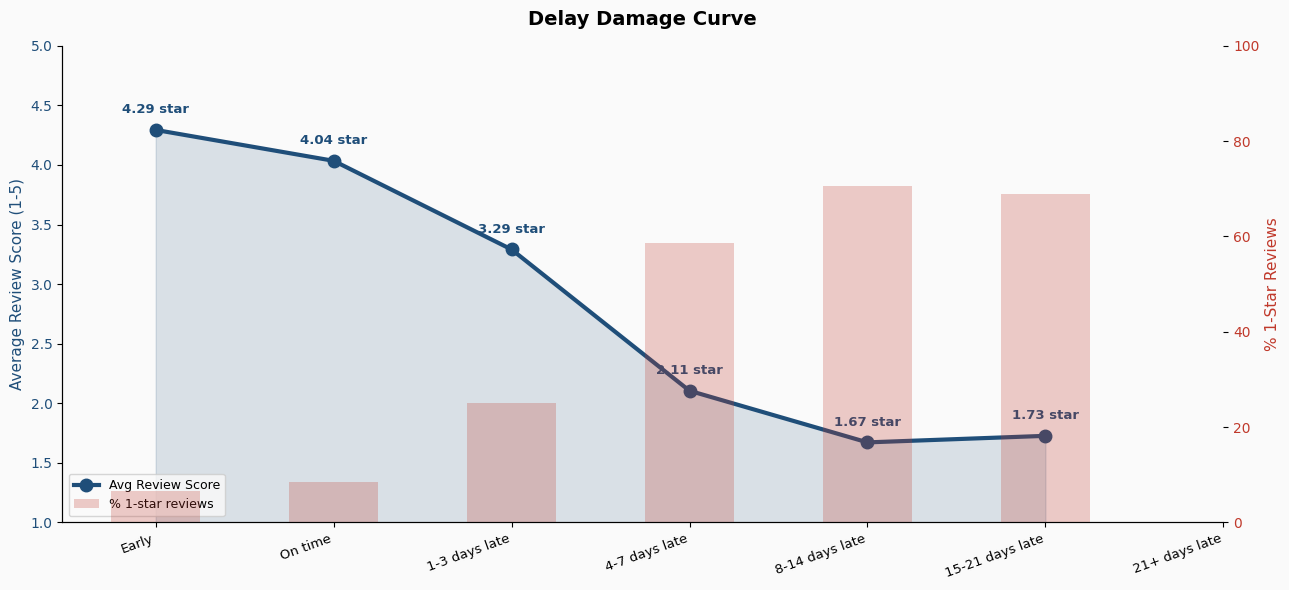

PLOT 3 — DELAY-DAMAGE CURVE DATA:
   delay_bucket  orders  avg_score  pct_1star  pct_5star
          Early 88149.0   4.294274   6.592247  62.448808
        On time  1280.0   4.035156   8.437500  50.546875
  1-3 days late  1852.0   3.291037  25.161987  33.207343
  4-7 days late  1747.0   2.105323  58.557527  14.138523
 8-14 days late  1446.0   1.672199  70.608575   6.915629
15-21 days late  1334.0   1.727136  68.815592   7.196402
  21+ days late     NaN        NaN        NaN        NaN



In [ ]:
# PLOT 3 — The Delay-Damage Curve (Line + Area chart)
delay_order = ['Early', 'On time', '1-3 days late',
               '4-7 days late', '8-14 days late',
               '15-21 days late', '21+ days late']

# Create delay_bucket column
conditions = [
    master_clean['trust_gap_days'] < 0,
    master_clean['trust_gap_days'] == 0,
    (master_clean['trust_gap_days'] > 0) & (master_clean['trust_gap_days'] <= 3),
    (master_clean['trust_gap_days'] > 3) & (master_clean['trust_gap_days'] <= 7),
    (master_clean['trust_gap_days'] > 7) & (master_clean['trust_gap_days'] <= 14),
    (master_clean['trust_gap_days'] > 14) & (master_clean['trust_gap_days'] <= 21),
    master_clean['trust_gap_days'] > 21
]
master_clean['delay_bucket'] = np.select(
    conditions, delay_order, default='Unknown'
)

# Now calculate delay_summary
delay_summary = (
    master_clean
    .groupby('delay_bucket', observed=True)
    .agg(
        orders     = ('review_score', 'count'),
        avg_score  = ('review_score', 'mean'),
        pct_1star  = ('review_score', lambda x: (x == 1).mean() * 100),
        pct_5star  = ('review_score', lambda x: (x == 5).mean() * 100)
    )
    .reindex(delay_order)
    .reset_index()
)

x = range(len(delay_summary))
fig, ax1 = plt.subplots(figsize=(13, 6))

# Main line — average review score
ax1.plot(x, delay_summary['avg_score'],
         color='#1F4E79', linewidth=3, marker='o', markersize=9,
         zorder=5, label='Avg Review Score')
ax1.fill_between(x, delay_summary['avg_score'], alpha=0.15, color='#1F4E79')

# Second y-axis — % 1-star reviews
ax2 = ax1.twinx()
ax2.bar(x, delay_summary['pct_1star'],
        alpha=0.25, color='#C0392B', width=0.5, label='% 1-star reviews')
ax2.set_ylabel('% 1-Star Reviews', color='#C0392B', fontsize=11)
ax2.tick_params(axis='y', labelcolor='#C0392B')
ax2.set_ylim(0, 100)

# Labels on line
for i, (score, pct) in enumerate(zip(delay_summary['avg_score'],
                                      delay_summary['pct_1star'])):
    ax1.annotate(f'{score:.2f} star',
                 xy=(i, score), xytext=(0, 12),
                 textcoords='offset points', ha='center',
                 fontsize=9.5, fontweight='bold', color='#1F4E79')

ax1.set_xticks(x)
ax1.set_xticklabels(delay_summary['delay_bucket'], rotation=20, ha='right', fontsize=9.5)
ax1.set_ylabel('Average Review Score (1-5)', color='#1F4E79', fontsize=11)
ax1.set_ylim(1, 5)
ax1.set_title('Delay Damage Curve', pad=15)
ax1.tick_params(axis='y', labelcolor='#1F4E79')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower left', fontsize=9)

plt.tight_layout()
plt.savefig(SAVE_PATH + 'plot3_delay_damage_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print("PLOT 3 — DELAY-DAMAGE CURVE DATA:")
print(delay_summary[['delay_bucket','orders','avg_score','pct_1star','pct_5star']].to_string(index=False))
print()

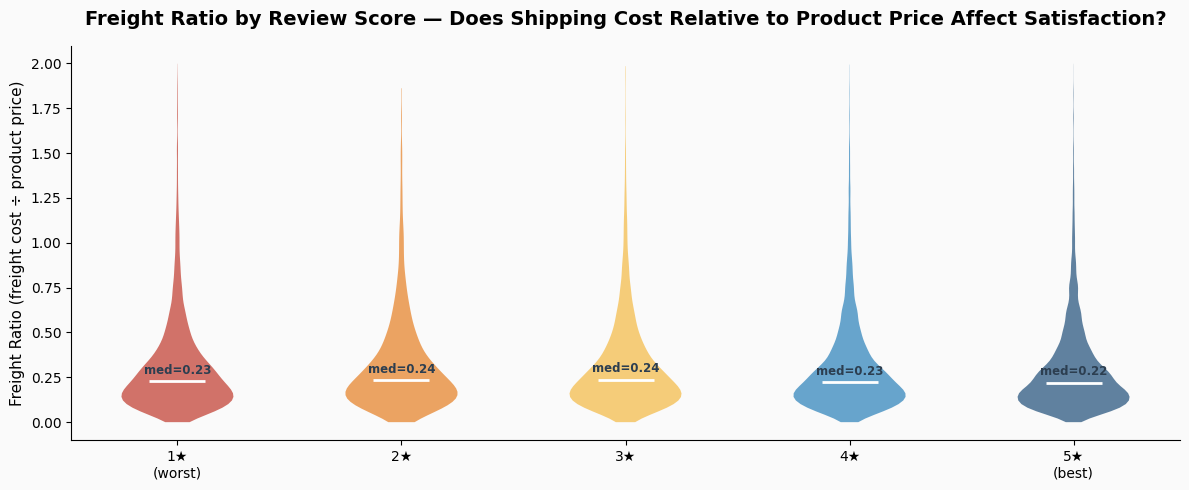

PLOT 4 — FREIGHT RATIO BY REVIEW SCORE (medians):
  1★  median=0.232  mean=0.319
  2★  median=0.236  mean=0.325
  3★  median=0.238  mean=0.326
  4★  median=0.225  mean=0.313
  5★  median=0.222  mean=0.302


In [ ]:
# PLOT 4 — Freight Ratio vs Review Score (Violin plot)
plot_df = master_clean[master_clean['freight_ratio'] <= 2.0].copy()
plot_df['review_score_label'] = plot_df['review_score'].map(
    {1: '1★', 2: '2★', 3: '3★', 4: '4★', 5: '5★'}
)

fig, ax = plt.subplots(figsize=(12, 5))

parts = ax.violinplot(
    [plot_df[plot_df['review_score'] == s]['freight_ratio'].values
     for s in [1, 2, 3, 4, 5]],
    positions=[1, 2, 3, 4, 5],
    showmedians=True,
    showextrema=False
)

# Color each violin by score
for i, (pc, score) in enumerate(zip(parts['bodies'], [1, 2, 3, 4, 5])):
    pc.set_facecolor(SCORE_COLORS[score])
    pc.set_alpha(0.7)
parts['cmedians'].set_color('white')
parts['cmedians'].set_linewidth(2)

ax.set_xticks([1, 2, 3, 4, 5])
ax.set_xticklabels(['1★\n(worst)', '2★', '3★', '4★', '5★\n(best)'])
ax.set_ylabel('Freight Ratio (freight cost ÷ product price)')
ax.set_title('Freight Ratio by Review Score — Does Shipping Cost Relative to Product Price Affect Satisfaction?', pad=15)

# Add median labels
for score in [1, 2, 3, 4, 5]:
    med = plot_df[plot_df['review_score'] == score]['freight_ratio'].median()
    ax.text(score, med + 0.04, f'med={med:.2f}',
            ha='center', fontsize=8.5, color='#2C3E50', fontweight='bold')

plt.tight_layout()
plt.savefig(SAVE_PATH + 'plot4_freight_ratio_violin.png', dpi=150, bbox_inches='tight')
plt.show()

# Print medians
print("PLOT 4 — FREIGHT RATIO BY REVIEW SCORE (medians):")
for s in [1, 2, 3, 4, 5]:
    med  = master_clean[master_clean['review_score'] == s]['freight_ratio'].median()
    mean = master_clean[master_clean['review_score'] == s]['freight_ratio'].mean()
    print(f"  {s}★  median={med:.3f}  mean={mean:.3f}")

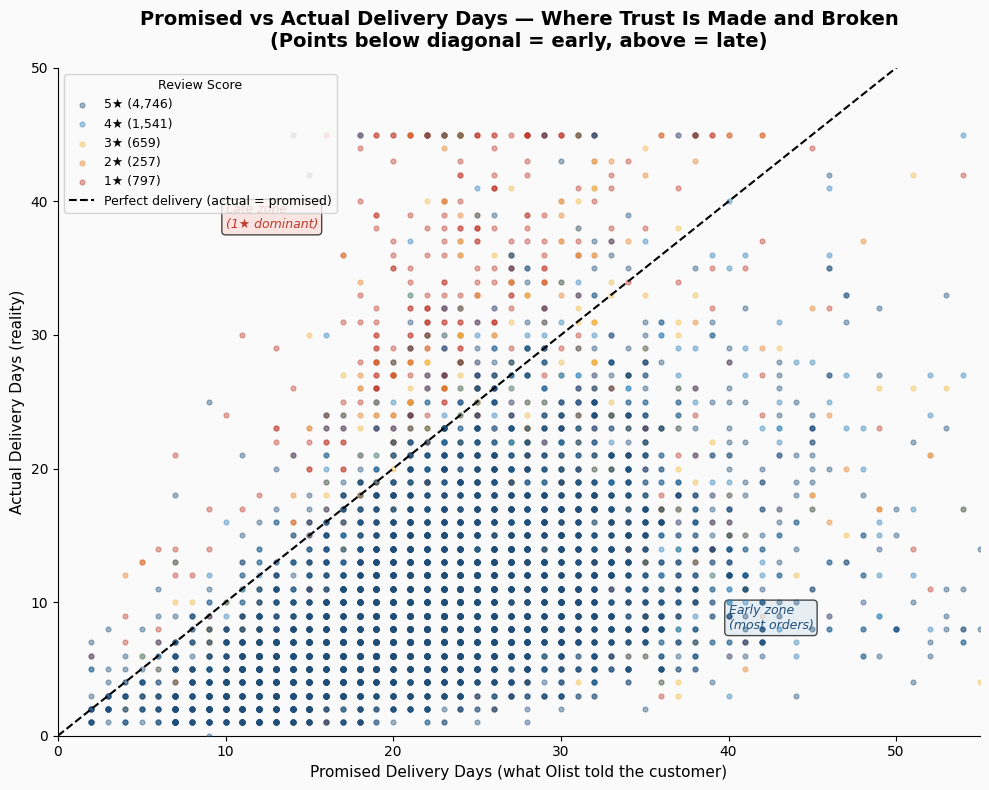

PLOT 5 — PROMISED vs ACTUAL DELIVERY:
  Orders where actual < promised (early): 87,325
  Orders where actual = promised (on time): 1,370
  Orders where actual > promised (late): 7,113
  Avg buffer built in by Olist: 11.5 days


In [ ]:
# PLOT 5 — Actual vs Promised Delivery Days (Scatter + Diagonal)
sample = master_clean.sample(8000, random_state=42)

fig, ax = plt.subplots(figsize=(10, 8))

# Plot each score as separate scatter layer (lower scores on top)
for score in [5, 4, 3, 2, 1]:
    subset = sample[sample['review_score'] == score]
    ax.scatter(
        subset['promised_delivery_days'],
        subset['actual_delivery_days'],
        c=SCORE_COLORS[score],
        alpha=0.4,
        s=12,
        label=f'{score}★ ({len(subset):,})',
        zorder=score
    )

# Perfect promise line (y = x)
max_val = min(sample[['promised_delivery_days','actual_delivery_days']].max().max(), 60)
ax.plot([0, max_val], [0, max_val], color='black', linewidth=1.5,
        linestyle='--', label='Perfect delivery (actual = promised)', zorder=10)

ax.set_xlabel('Promised Delivery Days (what Olist told the customer)')
ax.set_ylabel('Actual Delivery Days (reality)')
ax.set_title('Promised vs Actual Delivery Days — Where Trust Is Made and Broken\n(Points below diagonal = early, above = late)', pad=15)
ax.legend(title='Review Score', fontsize=9, title_fontsize=9)
ax.set_xlim(0, 55)
ax.set_ylim(0, 50)

# Annotate regions
ax.text(40, 8, 'Early zone\n(most orders)', fontsize=9,
        color='#1F4E79', style='italic',
        bbox=dict(facecolor='#DEEAF1', alpha=0.7, boxstyle='round'))
ax.text(10, 38, 'Late zone\n(1★ dominant)', fontsize=9,
        color='#C0392B', style='italic',
        bbox=dict(facecolor='#FADBD8', alpha=0.7, boxstyle='round'))

plt.tight_layout()
plt.savefig(SAVE_PATH + 'plot5_promised_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

print("PLOT 5 — PROMISED vs ACTUAL DELIVERY:")
print(f"  Orders where actual < promised (early): {(master_clean['actual_delivery_days'] < master_clean['promised_delivery_days']).sum():,}")
print(f"  Orders where actual = promised (on time): {(master_clean['actual_delivery_days'] == master_clean['promised_delivery_days']).sum():,}")
print(f"  Orders where actual > promised (late): {(master_clean['actual_delivery_days'] > master_clean['promised_delivery_days']).sum():,}")
print(f"  Avg buffer built in by Olist: {(master_clean['promised_delivery_days'] - master_clean['actual_delivery_days']).mean():.1f} days")

In [ ]:
# FINAL SUMMARY PRINTOUT
print("KEY STATISTICAL FINDINGS:")
print(f"  Trust gap skewness:  {master_clean['trust_gap_days'].skew():.3f}")
print(f"  % early deliveries:  {(master_clean['trust_gap_days'] < 0).mean()*100:.1f}%")
print(f"  % late deliveries:   {(master_clean['trust_gap_days'] > 0).mean()*100:.1f}%")
print(f"  Avg Olist buffer:    {(master_clean['promised_delivery_days'] - master_clean['actual_delivery_days']).mean():.1f} days")
print(f"  Class imbalance:     5-star = {(master_clean['review_score']==5).mean()*100:.1f}%")

KEY STATISTICAL FINDINGS:
  Trust gap skewness:  0.361
  % early deliveries:  92.0%
  % late deliveries:   6.7%
  Avg Olist buffer:    11.5 days
  Class imbalance:     5-star = 59.2%


In [ ]:
plt.rcParams.update({
    'figure.facecolor'  : '#FAFAFA',
    'axes.facecolor'    : '#FAFAFA',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.titlesize'    : 14,
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 11,
    'xtick.labelsize'   : 9.5,
    'ytick.labelsize'   : 9.5,
})

SAVE_PATH    = '/content/drive/MyDrive/olist_project/eda_plots/'
SCORE_COLORS = {1: '#C0392B', 2: '#E67E22', 3: '#F4B942',
                4: '#2980B9', 5: '#1F4E79'}

In [ ]:
delay_labels = ['Early', 'On time', '1-3 days late',
                '4-7 days late', '8-14 days late',
                '15-21 days late', '21+ days late']

master_clean['delay_bucket'] = pd.cut(
    master_clean['trust_gap_days'],
    bins   = [-999, -0.001, 0, 3, 7, 14, 21, 999],
    labels = delay_labels
)

In [ ]:
bucket_check = master_clean['delay_bucket'].value_counts()
print("DELAY BUCKET VERIFICATION (all 7 must have counts):")
for label in delay_labels:
    count = bucket_check.get(label, 0)
    print(f"  {label:<20} {count:>6,}")
print()

DELAY BUCKET VERIFICATION (all 7 must have counts):
  Early                88,149
  On time               1,280
  1-3 days late         1,852
  4-7 days late         1,747
  8-14 days late        1,446
  15-21 days late       1,334
  21+ days late             0



In [ ]:
state_summary = (
    master_clean
    .groupby('customer_state')
    .agg(
        orders         = ('review_score', 'count'),
        avg_score      = ('review_score', 'mean'),
        avg_gap        = ('trust_gap_days', 'mean'),
        avg_actual_days= ('actual_delivery_days', 'mean'),
        pct_late       = ('trust_gap_days', lambda x: (x > 0).mean() * 100),
        pct_1star      = ('review_score', lambda x: (x == 1).mean() * 100)
    )
    .reset_index()
    .sort_values('avg_score', ascending=True)  # worst states first
)

In [ ]:
print("STATE SUMMARY — ALL 27 STATES (sorted by avg review score):")
print()
print(f"{'State':<8} {'Orders':>7} {'Avg Score':>10} {'Avg Gap':>9} {'Actual Days':>12} {'% Late':>8} {'% 1-star':>9}")
for _, row in state_summary.iterrows():
    print(f"  {row['customer_state']:<6} {row['orders']:>7,} {row['avg_score']:>10.3f} "
          f"{row['avg_gap']:>9.1f} {row['avg_actual_days']:>12.1f} "
          f"{row['pct_late']:>8.1f}% {row['pct_1star']:>8.1f}%")
print()

STATE SUMMARY — ALL 27 STATES (sorted by avg review score):

State     Orders  Avg Score   Avg Gap  Actual Days   % Late  % 1-star
  MA         711      3.833      -9.7         20.6     17.2%     15.8%
  AL         394      3.858      -8.9         23.5     20.8%     15.0%
  RR          41      3.902     -18.7         24.2     12.2%     12.2%
  SE         334      3.907     -11.0         19.9     15.0%     15.3%
  PA         933      3.910     -14.4         22.5     10.7%     14.5%
  BA       3,229      3.931     -11.2         18.3     11.9%     13.2%
  CE       1,272      3.939     -11.4         20.0     13.7%     13.7%
  RJ      12,209      3.964     -12.1         14.4     11.9%     14.8%
  PI         471      3.994     -12.0         18.2     13.8%     13.0%
  PB         512      4.076     -13.5         19.5     10.2%     10.9%
  ES       1,969      4.079     -10.8         14.9     10.4%     11.0%
  PE       1,579      4.082     -13.5         17.6      9.4%     11.6%
  AC          80 

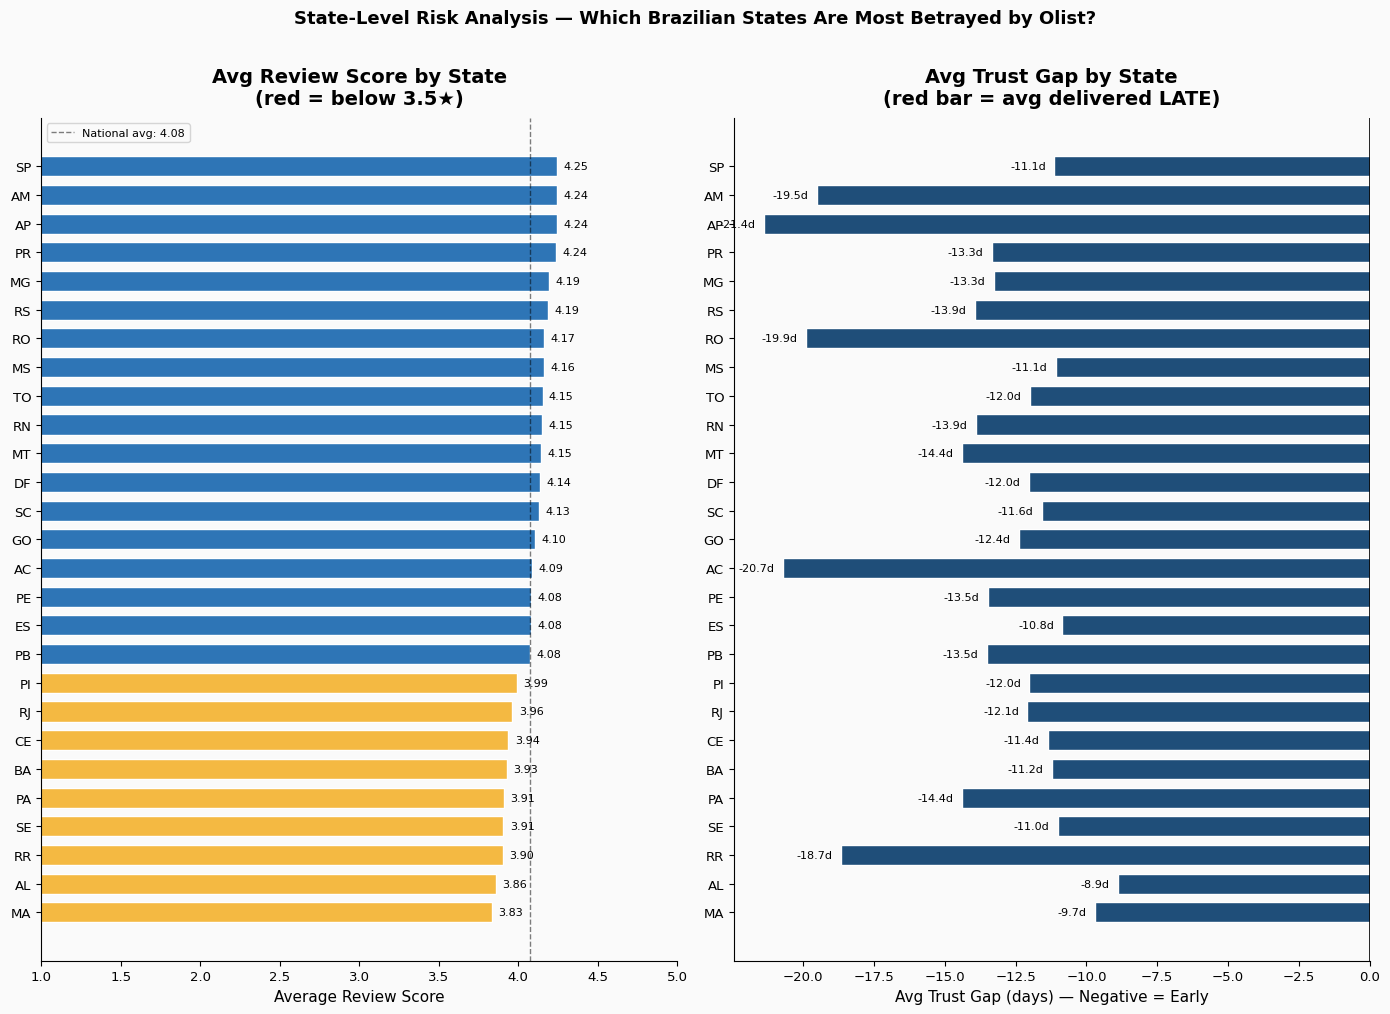

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 10))

scores_sorted = state_summary.set_index('customer_state')['avg_score']
colors_left   = ['#C0392B' if s < 3.5 else '#F4B942' if s < 4.0
                 else '#2E75B6' for s in scores_sorted]

axes[0].barh(scores_sorted.index, scores_sorted.values,
             color=colors_left, height=0.7, edgecolor='white')
axes[0].axvline(scores_sorted.mean(), color='black', linestyle='--',
                linewidth=1, alpha=0.5, label=f'National avg: {scores_sorted.mean():.2f}')
axes[0].set_xlabel('Average Review Score')
axes[0].set_title('Avg Review Score by State\n(red = below 3.5★)', pad=10)
axes[0].set_xlim(1, 5)
for i, (state, score) in enumerate(scores_sorted.items()):
    axes[0].text(score + 0.04, i, f'{score:.2f}', va='center', fontsize=8)
axes[0].legend(fontsize=8)

gap_sorted  = state_summary.set_index('customer_state')['avg_gap'].reindex(
    scores_sorted.index)
colors_right = ['#C0392B' if g > 0 else '#1F4E79' for g in gap_sorted]

axes[1].barh(gap_sorted.index, gap_sorted.values,
             color=colors_right, height=0.7, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=1.2)
axes[1].set_xlabel('Avg Trust Gap (days) — Negative = Early')
axes[1].set_title('Avg Trust Gap by State\n(red bar = avg delivered LATE)', pad=10)
for i, (state, gap) in enumerate(gap_sorted.items()):
    axes[1].text(gap + (0.3 if gap >= 0 else -0.3), i,
                 f'{gap:.1f}d', va='center', ha='left' if gap >= 0 else 'right',
                 fontsize=8)

plt.suptitle('State-Level Risk Analysis — Which Brazilian States Are Most Betrayed by Olist?',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(SAVE_PATH + 'plot6_state_risk_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
worst_states = state_summary.head(5)[['customer_state','avg_score','pct_late','avg_actual_days']]
best_states  = state_summary.tail(5)[['customer_state','avg_score','pct_late','avg_actual_days']]
print("TOP 5 WORST STATES (lowest avg review score):")
print(worst_states.to_string(index=False))
print("\nTOP 5 BEST STATES (highest avg review score):")
print(best_states.to_string(index=False))
print()

TOP 5 WORST STATES (lowest avg review score):
customer_state  avg_score  pct_late  avg_actual_days
            MA   3.832630 17.158931        20.582278
            AL   3.857868 20.812183        23.543147
            RR   3.902439 12.195122        24.170732
            SE   3.907186 14.970060        19.856287
            PA   3.909968 10.718114        22.493033

TOP 5 BEST STATES (highest avg review score):
customer_state  avg_score  pct_late  avg_actual_days
            MG   4.192342  4.476157        11.456479
            PR   4.240612  3.959184        11.459796
            AP   4.242424  3.030303        24.515152
            AM   4.243056  2.777778        25.166667
            SP   4.246578  4.431307         8.214412



In [ ]:
cat_summary = (
    master_clean
    .groupby('product_category_name_english')
    .agg(
        orders    = ('review_score', 'count'),
        avg_score = ('review_score', 'mean'),
        pct_1star = ('review_score', lambda x: (x == 1).mean() * 100),
        avg_gap   = ('trust_gap_days', 'mean')
    )
    .reset_index()
    .query('orders >= 100')
    .sort_values('avg_score', ascending=True)
)

In [ ]:
print(f"Categories with 100+ orders: {len(cat_summary)}")

Categories with 100+ orders: 52


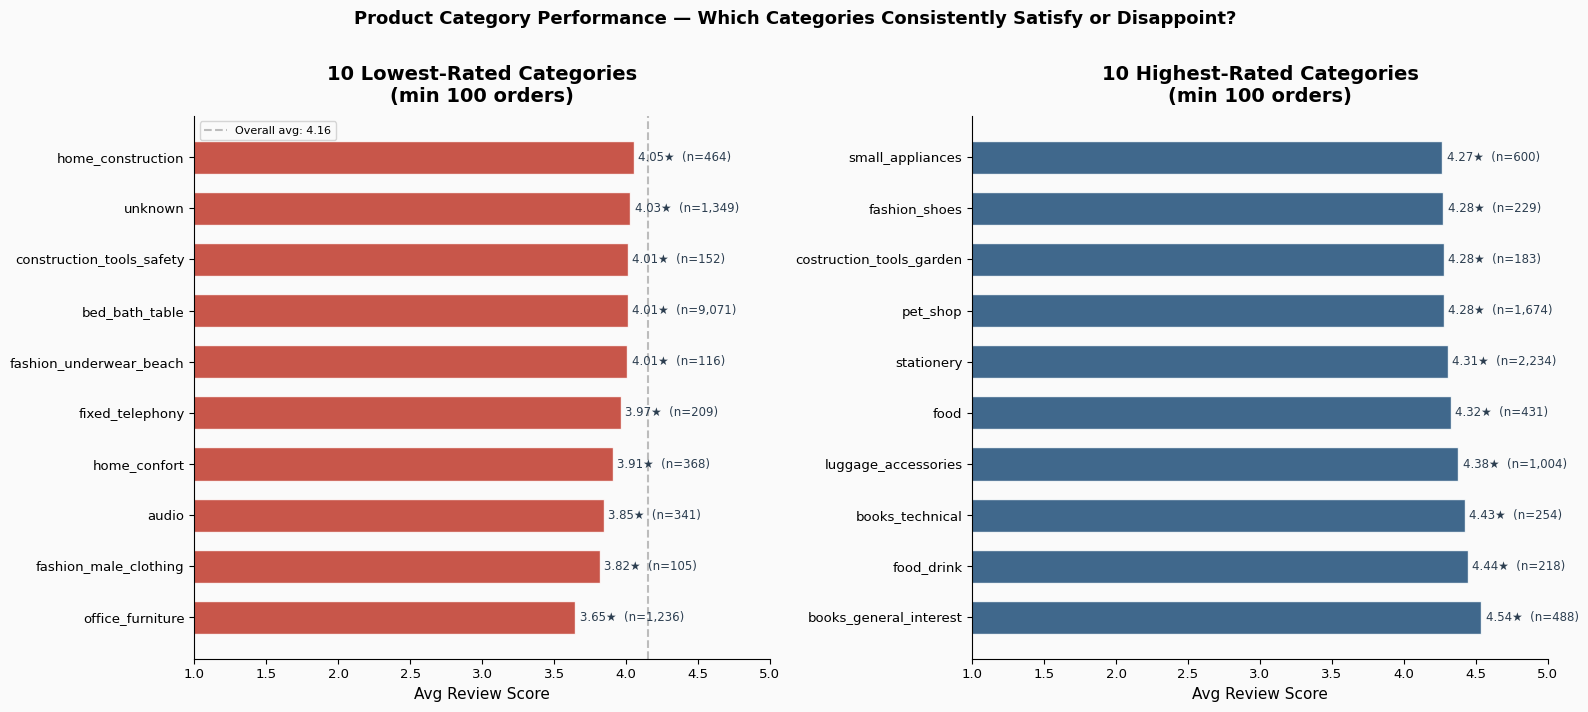

In [ ]:
worst_cats = cat_summary.head(10)
best_cats  = cat_summary.tail(10).sort_values('avg_score', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Worst 10
axes[0].barh(
    worst_cats['product_category_name_english'],
    worst_cats['avg_score'],
    color='#C0392B', height=0.65, edgecolor='white', alpha=0.85
)
for i, (_, row) in enumerate(worst_cats.iterrows()):
    axes[0].text(row['avg_score'] + 0.03, i,
                 f"{row['avg_score']:.2f}★  (n={row['orders']:,})",
                 va='center', fontsize=8.5, color='#2C3E50')
axes[0].set_xlim(1, 5)
axes[0].set_title('10 Lowest-Rated Categories\n(min 100 orders)', pad=10)
axes[0].set_xlabel('Avg Review Score')
axes[0].axvline(master_clean['review_score'].mean(), color='gray',
                linestyle='--', alpha=0.5,
                label=f'Overall avg: {master_clean["review_score"].mean():.2f}')
axes[0].legend(fontsize=8)

# Best 10
axes[1].barh(
    best_cats['product_category_name_english'],
    best_cats['avg_score'],
    color='#1F4E79', height=0.65, edgecolor='white', alpha=0.85
)
for i, (_, row) in enumerate(best_cats.iterrows()):
    axes[1].text(row['avg_score'] + 0.03, i,
                 f"{row['avg_score']:.2f}★  (n={row['orders']:,})",
                 va='center', fontsize=8.5, color='#2C3E50')
axes[1].set_xlim(1, 5)
axes[1].set_title('10 Highest-Rated Categories\n(min 100 orders)', pad=10)
axes[1].set_xlabel('Avg Review Score')

plt.suptitle('Product Category Performance — Which Categories Consistently Satisfy or Disappoint?',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(SAVE_PATH + 'plot7_category_performance.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
print("WORST 5 CATEGORIES:")
print(worst_cats[['product_category_name_english','orders','avg_score','pct_1star']].head(5).to_string(index=False))
print("\nBEST 5 CATEGORIES:")
print(best_cats[['product_category_name_english','orders','avg_score','pct_1star']].head(5).to_string(index=False))
print()

WORST 5 CATEGORIES:
product_category_name_english  orders  avg_score  pct_1star
             office_furniture    1236   3.648058  17.233010
        fashion_male_clothing     105   3.819048  20.000000
                        audio     341   3.847507  16.129032
                 home_confort     368   3.907609  13.586957
              fixed_telephony     209   3.966507  13.875598

BEST 5 CATEGORIES:
product_category_name_english  orders  avg_score  pct_1star
       books_general_interest     488   4.538934   5.122951
                   food_drink     218   4.444954   2.752294
              books_technical     254   4.425197   6.692913
          luggage_accessories    1004   4.379482   5.677291
                         food     431   4.324826   7.888631



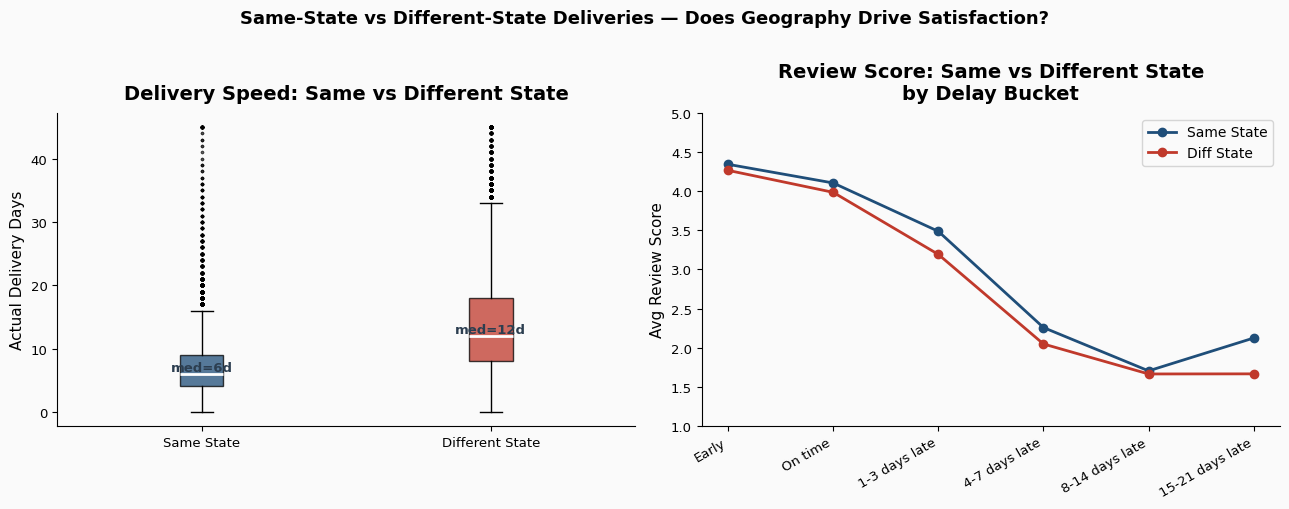

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: actual_delivery_days by same_state
same_state_data  = master_clean[master_clean['same_state']==1]['actual_delivery_days']
diff_state_data  = master_clean[master_clean['same_state']==0]['actual_delivery_days']

bp = axes[0].boxplot(
    [same_state_data, diff_state_data],
    labels=['Same State', 'Different State'],
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2),
    flierprops=dict(marker='.', alpha=0.2, markersize=3)
)
bp['boxes'][0].set_facecolor('#1F4E79')
bp['boxes'][1].set_facecolor('#C0392B')
bp['boxes'][0].set_alpha(0.75)
bp['boxes'][1].set_alpha(0.75)

axes[0].set_ylabel('Actual Delivery Days')
axes[0].set_title('Delivery Speed: Same vs Different State', pad=10)

# Annotate medians
for i, data in enumerate([same_state_data, diff_state_data], 1):
    axes[0].text(i, data.median() + 0.5, f'med={data.median():.0f}d',
                 ha='center', fontsize=9.5, fontweight='bold',
                 color='#2C3E50')

# Right: avg review score by same_state and delay bucket
same_state_score = (
    master_clean
    .groupby(['same_state', 'delay_bucket'], observed=True)['review_score']
    .mean()
    .reset_index()
)
same_state_score['label'] = same_state_score['same_state'].map(
    {0: 'Diff State', 1: 'Same State'})

for label, color in [('Same State', '#1F4E79'), ('Diff State', '#C0392B')]:
    subset = same_state_score[same_state_score['label'] == label]
    axes[1].plot(
        subset['delay_bucket'].astype(str),
        subset['review_score'],
        marker='o', linewidth=2, markersize=6,
        color=color, label=label
    )

axes[1].set_xticklabels(delay_labels, rotation=30, ha='right')
axes[1].set_ylabel('Avg Review Score')
axes[1].set_title('Review Score: Same vs Different State\nby Delay Bucket', pad=10)
axes[1].set_ylim(1, 5)
axes[1].legend()

plt.suptitle('Same-State vs Different-State Deliveries — Does Geography Drive Satisfaction?',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(SAVE_PATH + 'plot8_same_state_impact.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
print("SAME-STATE vs DIFFERENT-STATE STATS:\n")
for flag, label in [(1, 'Same State'), (0, 'Diff State')]:
    subset = master_clean[master_clean['same_state']==flag]
    print(f"\n  {label} ({len(subset):,} orders):")
    print(f"    Avg delivery days: {subset['actual_delivery_days'].mean():.1f}")
    print(f"    Median delivery days: {subset['actual_delivery_days'].median():.0f}")
    print(f"    Avg review score: {subset['review_score'].mean():.3f}")
    print(f"    % late: {(subset['trust_gap_days']>0).mean()*100:.1f}%")
print()

SAME-STATE vs DIFFERENT-STATE STATS:


  Same State (34,486 orders):
    Avg delivery days: 7.4
    Median delivery days: 6
    Avg review score: 4.264
    % late: 4.5%

  Diff State (61,322 orders):
    Avg delivery days: 14.4
    Median delivery days: 12
    Avg review score: 4.096
    % late: 7.9%



In [ ]:
numeric_features = [
    'trust_gap_days', 'actual_delivery_days', 'promised_delivery_days',
    'approval_lag_days', 'shipping_lag_days',
    'total_price', 'total_freight', 'freight_ratio', 'item_count',
    'payment_installments', 'payment_value',
    'product_weight_g', 'product_volume_cm3',
    'same_state', 'is_credit_card', 'high_installments',
    'order_value_total', 'review_score'
]

In [ ]:
corr_matrix = master_clean[numeric_features].corr().round(3)
corr_matrix

NameError: name 'numeric_features' is not defined

NameError: name 'corr_matrix' is not defined

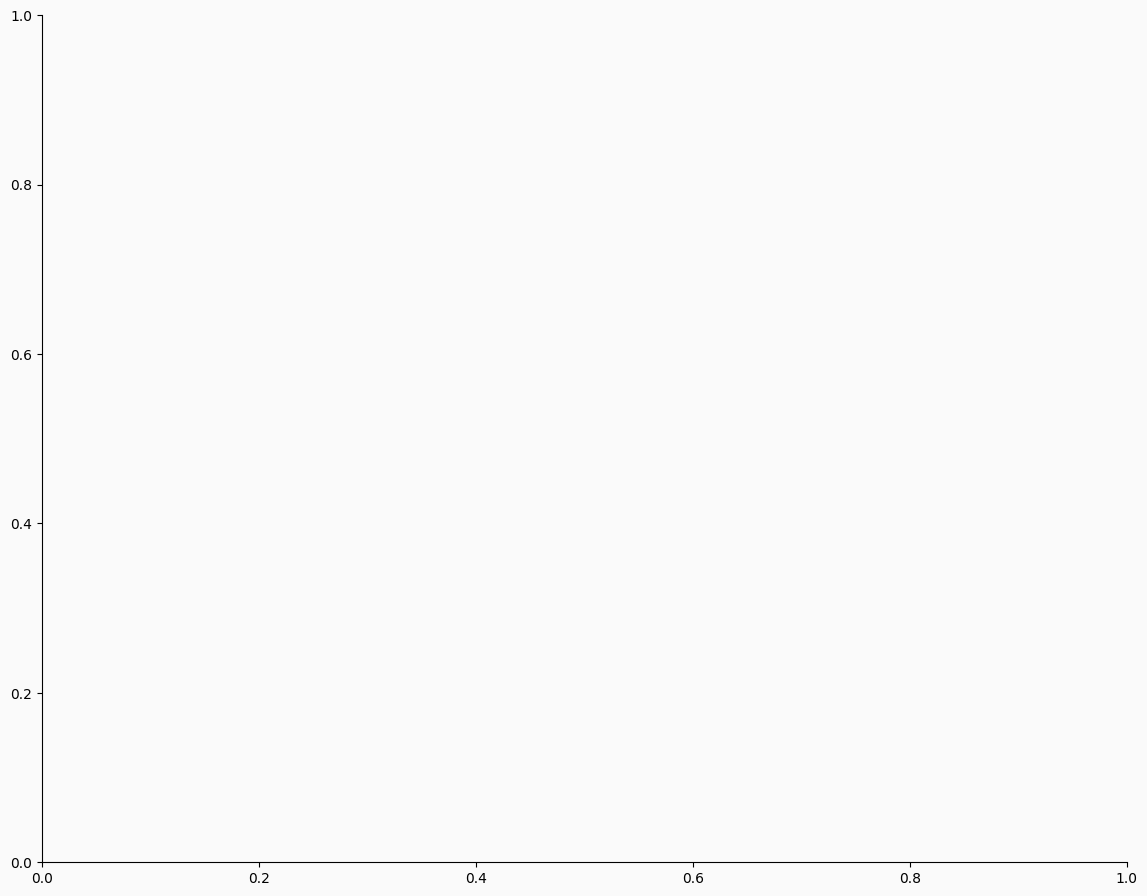

In [ ]:

fig, ax = plt.subplots(figsize=(14, 11))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # upper triangle mask

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 7.5},
    ax=ax
)

ax.set_title('Feature Correlation Matrix',
             pad=15, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_PATH + 'plot9_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
print("TOP CORRELATIONS WITH review_score (target):\n")
target_corr = corr_matrix['review_score'].drop('review_score').sort_values()
for feat, corr_val in target_corr.items():
    direction = '(negative)' if corr_val < 0 else '(positive)'
    print(f"  {feat:<28} {corr_val:>7.3f}  {direction}")
print()

TOP CORRELATIONS WITH review_score (target):

  actual_delivery_days          -0.349  (negative)
  trust_gap_days                -0.276  (negative)
  shipping_lag_days             -0.157  (negative)
  item_count                    -0.123  (negative)
  total_freight                 -0.090  (negative)
  promised_delivery_days        -0.053  (negative)
  payment_value                 -0.042  (negative)
  order_value_total             -0.042  (negative)
  total_price                   -0.035  (negative)
  payment_installments          -0.031  (negative)
  product_weight_g              -0.029  (negative)
  product_volume_cm3            -0.025  (negative)
  freight_ratio                 -0.023  (negative)
  high_installments             -0.021  (negative)
  approval_lag_days             -0.017  (negative)
  is_credit_card                -0.001  (negative)
  same_state                     0.063  (positive)



## PRE-MODELING PREPARATION

In [ ]:
print("MULTICOLLINEARITY FLAGS (|corr| > 0.70 between features):\n")
found = False
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        c = corr_matrix.iloc[i, j]
        if abs(c) > 0.70:
            col_i = corr_matrix.columns[i]
            col_j = corr_matrix.columns[j]
            if col_i != 'review_score' and col_j != 'review_score':
                print(f" {col_i} vs {col_j}: {c:.3f}")
                found = True
if not found:
    print("  No severe multicollinearity detected (all feature pairs < 0.70)")
print()

MULTICOLLINEARITY FLAGS (|corr| > 0.70 between features):

 total_price vs payment_value: 0.996
 total_price vs order_value_total: 0.996
 payment_installments vs high_installments: 0.860
 payment_value vs order_value_total: 1.000
 product_weight_g vs product_volume_cm3: 0.803



In [ ]:
master_clean['order_month'] = pd.to_datetime(
    master_clean['order_purchase_timestamp']
).dt.to_period('M')

monthly = (
    master_clean
    .groupby('order_month')
    .agg(
        orders    = ('review_score', 'count'),
        avg_score = ('review_score', 'mean')
    )
    .reset_index()
)
monthly['order_month_str'] = monthly['order_month'].astype(str)
monthly['order_month_str']

,order_month_str
0,2016-10
1,2016-12
2,2017-01
3,2017-02
4,2017-03
5,2017-04
6,2017-05
7,2017-06
8,2017-07
9,2017-08


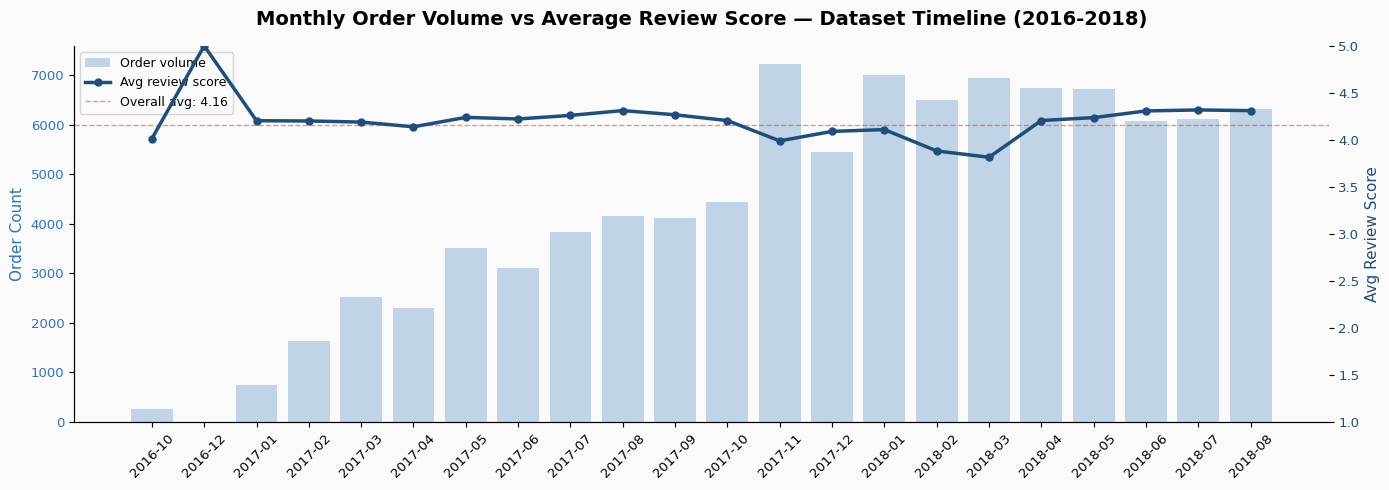

In [ ]:
fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.bar(monthly['order_month_str'], monthly['orders'],
        color='#A9C4E0', alpha=0.7, label='Order volume', zorder=2)
ax1.set_ylabel('Order Count', color='#2E75B6')
ax1.tick_params(axis='x', rotation=45)
ax1.tick_params(axis='y', labelcolor='#2E75B6')

ax2 = ax1.twinx()
ax2.plot(monthly['order_month_str'], monthly['avg_score'],
         color='#1F4E79', linewidth=2.5, marker='o', markersize=5,
         label='Avg review score', zorder=5)
ax2.set_ylabel('Avg Review Score', color='#1F4E79')
ax2.set_ylim(1, 5)
ax2.tick_params(axis='y', labelcolor='#1F4E79')
ax2.axhline(master_clean['review_score'].mean(), color='#C0392B',
            linestyle='--', alpha=0.5, linewidth=1,
            label=f'Overall avg: {master_clean["review_score"].mean():.2f}')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

ax1.set_title('Monthly Order Volume vs Average Review Score — Dataset Timeline (2016-2018)',
              pad=15)
plt.tight_layout()
plt.savefig(SAVE_PATH + 'plot10_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
print("MONTHLY SUMMARY (first and last 3 months):")
print(monthly[['order_month_str','orders','avg_score']].head(3).to_string(index=False))
print(monthly[['order_month_str','orders','avg_score']].tail(3).to_string(index=False))


MONTHLY SUMMARY (first and last 3 months):
order_month_str  orders  avg_score
        2016-10     262   4.011450
        2016-12       1   5.000000
        2017-01     739   4.202977
order_month_str  orders  avg_score
        2018-06    6072   4.307312
        2018-07    6118   4.317914
        2018-08    6330   4.310427


In [ ]:
cols_to_drop = [
    'order_value_total',
    'product_volume_cm3',
    'high_installments',
]

master_clean = master_clean.drop(columns=cols_to_drop)
print(f"After dropping 3 collinear features: {master_clean.shape}")

After dropping 3 collinear features: (95808, 36)


state_target_map = (
    master_clean
    .groupby('customer_state')['review_score']
    .mean()
    .round(4)
)
master_clean['state_risk_score'] = (
    master_clean['customer_state'].map(state_target_map)
)

print(f"\nSTATE TARGET ENCODING (avg review score per state):")
print(state_target_map.sort_values().to_string())

In [ ]:
master_sorted = master_clean.sort_values(
    'order_purchase_timestamp').reset_index(drop=True)
split_idx = int(len(master_sorted) * 0.80)

In [ ]:
SAVE_PATH = '/content/drive/MyDrive/olist_project/'

## Model

In [ ]:
train_df = master_sorted.iloc[:split_idx].copy()
test_df  = master_sorted.iloc[split_idx:].copy()

print(f"  Train: {len(train_df):,} orders")
print(f"  Test:  {len(test_df):,} orders")

  Train: 76,646 orders
  Test:  19,162 orders


seller_stats = (
    train_df
    .groupby('seller_id')
    .agg(
        seller_order_volume = ('order_id',       'count'),
        seller_late_rate    = ('trust_gap_days',  lambda x: (x > 0).mean()),
        seller_avg_gap      = ('trust_gap_days',  'mean'),
        seller_avg_score    = ('review_score',    'mean')
    )
    .reset_index()
)

global_avg_score = train_df['review_score'].mean()

train_df = train_df.merge(
    seller_stats[['seller_id', 'seller_order_volume',
                  'seller_late_rate', 'seller_avg_gap', 'seller_avg_score']],
    on='seller_id', how='left'
)
test_df = test_df.merge(
    seller_stats[['seller_id', 'seller_order_volume',
                  'seller_late_rate', 'seller_avg_gap', 'seller_avg_score']],
    on='seller_id', how='left'
)

train_df['seller_order_volume'] = train_df['seller_order_volume'].fillna(1)
#train_df['seller_late_rate']    = train_df['seller_late_rate'].fillna(global_avg_score)
train_df['seller_avg_gap']      = train_df['seller_avg_gap'].fillna(0)
train_df['seller_avg_score']    = train_df['seller_avg_score'].fillna(global_avg_score)

test_df['seller_order_volume']  = test_df['seller_order_volume'].fillna(1)
Z#test_df['seller_late_rate']     = test_df['seller_late_rate'].fillna(global_avg_score)
test_df['seller_avg_gap']       = test_df['seller_avg_gap'].fillna(0)
test_df['seller_avg_score']     = test_df['seller_avg_score'].fillna(global_avg_score)

global_late_rate = (train_df['trust_gap_days'] > 0).mean()  # = ~0.068 based on your data
train_df['seller_late_rate'] = train_df['seller_late_rate'].fillna(global_late_rate)
test_df['seller_late_rate']  = test_df['seller_late_rate'].fillna(global_late_rate)

print(f"  Unique sellers in training: {seller_stats.shape[0]:,}")
print(f"  Avg seller late rate: {seller_stats['seller_late_rate'].mean():.3f}")
print(f"  Seller with most orders: {seller_stats['seller_order_volume'].max():,}")
print(f"  Nulls in train seller cols: "
      f"{train_df[['seller_avg_score','seller_late_rate']].isnull().sum().sum()}")
print(f"  Nulls in test seller cols:  "
      f"{test_df[['seller_avg_score','seller_late_rate']].isnull().sum().sum()}")

In [ ]:
state_encode    = train_df.groupby('customer_state')['review_score'].mean()
category_encode = train_df.groupby('product_category_name_english')['review_score'].mean()
global_avg_score = train_df['review_score'].mean()
train_df['state_risk_score']    = train_df['customer_state'].map(state_encode).fillna(global_avg_score)
test_df['state_risk_score']     = test_df['customer_state'].map(state_encode).fillna(global_avg_score)

train_df['category_risk_score'] = train_df['product_category_name_english'].map(category_encode).fillna(global_avg_score)
test_df['category_risk_score']  = test_df['product_category_name_english'].map(category_encode).fillna(global_avg_score)

print(f"  State encodings: {train_df['customer_state'].nunique()} states in train")
print(f"  Category encodings: {train_df['product_category_name_english'].nunique()} categories in train")


  State encodings: 27 states in train
  Category encodings: 74 categories in train


In [ ]:
feature_cols = [
    'trust_gap_days', 'actual_delivery_days',
    'promised_delivery_days', 'shipping_lag_days', 'approval_lag_days',
    'total_price', 'total_freight', 'freight_ratio', 'item_count',
    'payment_installments', 'payment_value',
    'product_weight_g', 'product_length_cm',
    'product_height_cm', 'product_width_cm',
    'same_state', 'state_risk_score', 'category_risk_score',
    'pay_credit_card', 'pay_debit_card', 'pay_voucher',
    'seller_avg_score', 'seller_late_rate',
    'seller_avg_gap', 'seller_order_volume',
]

In [ ]:
print(f"  Total features: {len(feature_cols)} ")
feature_cols

  Total features: 25 


['trust_gap_days',
 'actual_delivery_days',
 'promised_delivery_days',
 'shipping_lag_days',
 'approval_lag_days',
 'total_price',
 'total_freight',
 'freight_ratio',
 'item_count',
 'payment_installments',
 'payment_value',
 'product_weight_g',
 'product_length_cm',
 'product_height_cm',
 'product_width_cm',
 'same_state',
 'state_risk_score',
 'category_risk_score',
 'pay_credit_card',
 'pay_debit_card',
 'pay_voucher',
 'seller_avg_score',
 'seller_late_rate',
 'seller_avg_gap',
 'seller_order_volume']

In [ ]:
# PAYMENT TYPE DUMMIES
payment_dummies = pd.get_dummies(
    master_sorted['payment_type'],
    prefix='pay',
    drop_first=False
)

master_sorted = pd.concat([master_sorted, payment_dummies], axis=1)

print("Payment dummies created:")
dummy_cols = [c for c in master_sorted.columns if c.startswith('pay_')]
for col in dummy_cols:
    count = master_sorted[col].sum()
    pct   = count / len(master_sorted) * 100
    print(f"  {col:<20} {int(count):>7,}  ({pct:.1f}%)")

# Verify the 3 we need exist
needed = ['pay_credit_card', 'pay_debit_card', 'pay_voucher']
for col in needed:
    assert col in master_sorted.columns, f"MISSING: {col}"
print(f"\nAll 3 required dummy columns confirmed.")
print(f"master_sorted shape after dummies: {master_sorted.shape}")

Payment dummies created:
  pay_boleto            19,048  (19.9%)
  pay_credit_card       72,724  (75.9%)
  pay_debit_card         1,477  (1.5%)
  pay_voucher            2,559  (2.7%)

All 3 required dummy columns confirmed.
master_sorted shape after dummies: (95808, 40)


In [ ]:
train_df = master_sorted.iloc[:split_idx].copy()
test_df  = master_sorted.iloc[split_idx:].copy()

print(f"  Train: {len(train_df):,} orders")
print(f"  Test:  {len(test_df):,} orders")

# Verify dummies now exist in both
for col in ['pay_credit_card', 'pay_debit_card', 'pay_voucher']:
    assert col in train_df.columns, f"MISSING in train_df: {col}"
    assert col in test_df.columns,  f"MISSING in test_df: {col}"
print("Dummies confirmed in train_df and test_df.")

  Train: 76,646 orders
  Test:  19,162 orders
Dummies confirmed in train_df and test_df.


In [ ]:
seller_stats = (
    train_df
    .groupby('seller_id')
    .agg(
        seller_order_volume = ('order_id',      'count'),
        seller_late_rate    = ('trust_gap_days', lambda x: (x > 0).mean()),
        seller_avg_gap      = ('trust_gap_days', 'mean'),
        seller_avg_score    = ('review_score',   'mean')
    )
    .reset_index()
)

global_avg_score = train_df['review_score'].mean()
global_late_rate = (train_df['trust_gap_days'] > 0).mean()  # = ~0.068 based on your data
print(f"  Global avg score: {global_avg_score:.4f}")
print(f"  Global late rate: {global_late_rate:.4f}")

train_df = train_df.merge(
    seller_stats[['seller_id', 'seller_order_volume',
                  'seller_late_rate', 'seller_avg_gap', 'seller_avg_score']],
    on='seller_id', how='left'
)
test_df = test_df.merge(
    seller_stats[['seller_id', 'seller_order_volume',
                  'seller_late_rate', 'seller_avg_gap', 'seller_avg_score']],
    on='seller_id', how='left'
)

train_df['seller_order_volume'] = train_df['seller_order_volume'].fillna(1)
train_df['seller_late_rate']    = train_df['seller_late_rate'].fillna(global_late_rate)
train_df['seller_avg_gap']      = train_df['seller_avg_gap'].fillna(0)
train_df['seller_avg_score']    = train_df['seller_avg_score'].fillna(global_avg_score)


test_df['seller_order_volume']  = test_df['seller_order_volume'].fillna(1)
test_df['seller_late_rate']     = test_df['seller_late_rate'].fillna(global_late_rate)
test_df['seller_avg_gap']       = test_df['seller_avg_gap'].fillna(0)
test_df['seller_avg_score']     = test_df['seller_avg_score'].fillna(global_avg_score)

print(f"  Unique sellers in training: {seller_stats.shape[0]:,}")
print(f"  Nulls in train seller cols: {train_df[['seller_avg_score','seller_late_rate']].isnull().sum().sum()}")
print(f"  Nulls in test seller cols:  {test_df[['seller_avg_score','seller_late_rate']].isnull().sum().sum()}")

  Global avg score: 4.1173
  Global late rate: 0.0747
  Unique sellers in training: 2,416
  Nulls in train seller cols: 0
  Nulls in test seller cols:  0


In [ ]:
state_encode    = train_df.groupby('customer_state')['review_score'].mean()
category_encode = train_df.groupby('product_category_name_english')['review_score'].mean()

train_df['state_risk_score']    = train_df['customer_state'].map(state_encode).fillna(global_avg_score)
test_df['state_risk_score']     = test_df['customer_state'].map(state_encode).fillna(global_avg_score)

train_df['category_risk_score'] = train_df['product_category_name_english'].map(category_encode).fillna(global_avg_score)
test_df['category_risk_score']  = test_df['product_category_name_english'].map(category_encode).fillna(global_avg_score)

print(f"  State encodings: {train_df['customer_state'].nunique()} states in train")
print(f"  Category encodings: {train_df['product_category_name_english'].nunique()} categories in train")

  State encodings: 27 states in train
  Category encodings: 74 categories in train


In [ ]:
X_train = train_df[feature_cols].astype(float).values
y_train = train_df['review_score'].values
X_test  = test_df[feature_cols].astype(float).values
y_test  = test_df['review_score'].values

print(f"  X_train shape: {X_train.shape}")
print(f"  X_test shape:  {X_test.shape}")
print(f"  X_train nulls: {np.isnan(X_train).sum()}")
print(f"  X_test nulls:  {np.isnan(X_test).sum()}")

  X_train shape: (76646, 25)
  X_test shape:  (19162, 25)
  X_train nulls: 0
  X_test nulls:  0


In [ ]:
np.random.seed(42)
sample_idx = np.random.choice(len(X_train), 15000, replace=False)
X_sample   = X_train[sample_idx]
y_sample   = y_train[sample_idx]

print(f"Training sample: {len(X_sample):,} rows")
print(f"Class distribution in sample:")
for cls in sorted(np.unique(y_sample)):
    count = (y_sample == cls).sum()
    print(f"  {cls}star: {count:,}")

Training sample: 15,000 rows
Class distribution in sample:
  1star: 1,578
  2star: 475
  3star: 1,268
  4star: 2,990
  5star: 8,689


## MODEL SELECTION: AutoML Validation

In [ ]:
automl = AutoML()

automl.fit(
    X_train      = X_sample,
    y_train      = y_sample,
    task         = 'classification',
    metric       = 'macro_f1',
    time_budget  = 180,         # seconds
    seed         = 42,
    verbose      = 1            # show progress
)

INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune


In [ ]:
print("AUTOML RESULTS")
print(f"  Best model found:       {automl.best_estimator}")
print(f"  Best CV macro F1:       {1 - automl.best_loss:.4f}")
print(f"  Time used:              {automl.time_to_find_best_model:.1f}s")

AUTOML RESULTS
  Best model found:       xgboost
  Best CV macro F1:       0.2778
  Time used:              173.9s


In [ ]:
# Evaluate best FLAML model on real test set
y_pred_automl = automl.predict(X_test)
f1_automl     = f1_score(y_test, y_pred_automl, average='macro')
print(f"  FLAML best model test macro F1: {f1_automl:.4f}")

  FLAML best model test macro F1: 0.2306


In [ ]:
# AutoML comparison table: what FLAML tried
print("MODELS TESTED BY FLAML:")
print(f"{'Model':<25} {'Config':<20} {'CV Loss':>10}")

try:
    # FLAML stores search history — extract it
    history = automl.model_history if hasattr(automl, 'model_history') else None
    if history:
        seen = set()
        for entry in history[:20]:
            model_name = entry.get('learner', 'unknown')
            loss = entry.get('val_loss', float('nan'))
            if model_name not in seen:
                print(f"  {model_name:<25} {'':20} {1-loss:>10.4f}")
                seen.add(model_name)
    else:
        print(f"  Best: {automl.best_estimator}")
        print("  (Full history not available in this FLAML version)")
except Exception:
    print(f"  Best model: {automl.best_estimator}")




MODELS TESTED BY FLAML:
Model                     Config                  CV Loss
  Best: xgboost
  (Full history not available in this FLAML version)


In [ ]:
print("AUTOML VALIDATION CONCLUSION:")
best = automl.best_estimator.lower()
if any(x in best for x in ['xgb', 'lgbm', 'gbm', 'boosting', 'gradient']):
    print(f"  CONFIRMED: FLAML selected '{automl.best_estimator}'")
else:
    print(f"  FLAML selected: {automl.best_estimator}")

AUTOML VALIDATION CONCLUSION:
  CONFIRMED: FLAML selected 'xgboost'


## FINAL MODEL TRAINING — XGBoost

In [ ]:
sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train - 1   # XGBoost expects 0-indexed labels
)

In [ ]:
xgb_final = xgb.XGBClassifier(
    n_estimators          = 500,
    max_depth             = 6,
    learning_rate         = 0.05,
    min_child_weight      = 5,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    reg_alpha             = 0.1,
    reg_lambda            = 1.0,
    eval_metric           = 'mlogloss',
    random_state          = 42,
    n_jobs                = -1,
    verbosity             = 0,
    early_stopping_rounds = 30
)

In [ ]:
xgb_final.fit(
    X_train, y_train - 1,
    sample_weight = sample_weights,
    eval_set      = [(X_test, y_test - 1)],
    verbose       = False
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=30,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=5, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=-1,
              num_parallel_tree=None, ...)

In [ ]:
best_iter = xgb_final.best_iteration
print(f"  Best iteration: {best_iter}")
if best_iter == 499:
    print("  NOTE: Early stopping did not trigger!")
else:
    print(f"  Early stopping triggered at tree {best_iter} — model converged")

  Best iteration: 53
  Early stopping triggered at tree 53 — model converged


## MODEL EVALUATION

In [ ]:
y_pred       = xgb_final.predict(X_test) + 1
y_pred_proba = xgb_final.predict_proba(X_test)
y_train_pred = xgb_final.predict(X_train) + 1

acc      = accuracy_score(y_test, y_pred)

f1_mac   = f1_score(y_test, y_pred, average='macro')
f1_wt    = f1_score(y_test, y_pred, average='weighted')
f1_per   = f1_score(y_test, y_pred, average=None, labels=[1,2,3,4,5])
mcc      = matthews_corrcoef(y_test, y_pred)
kappa    = cohen_kappa_score(y_test, y_pred)
ll       = log_loss(y_test, y_pred_proba)
train_f1 = f1_score(y_train, y_train_pred, average='macro')

y_test_bin = label_binarize(y_test, classes=[1,2,3,4,5])
roc_auc    = roc_auc_score(y_test_bin, y_pred_proba, multi_class='ovr', average='macro')

In [ ]:
print(f"  Accuracy:          {acc:.4f}  ({acc*100:.1f}%)")
print(f"  Macro F1:          {f1_mac:.4f}  (+{f1_mac-0.157:.4f} vs baseline 0.157)")
print(f"  Weighted F1:       {f1_wt:.4f}")
print(f"  MCC:               {mcc:.4f}  (0=random, 1=perfect)")
print(f"  Cohen Kappa:       {kappa:.4f}")
print(f"  Log Loss:          {ll:.4f}")
print(f"  ROC-AUC (macro):   {roc_auc:.4f}")

  Accuracy:          0.4236  (42.4%)
  Macro F1:          0.2581  (+0.1011 vs baseline 0.157)
  Weighted F1:       0.4580
  MCC:               0.0825  (0=random, 1=perfect)
  Cohen Kappa:       0.0793
  Log Loss:          1.4764
  ROC-AUC (macro):   0.5893


In [ ]:
print(f"    Train Macro F1:  {train_f1:.4f}")
print(f"    Test  Macro F1:  {f1_mac:.4f}")
gap = train_f1 - f1_mac
print(f"    Gap:             {gap:.4f}  ", end="")
if gap > 0.20:
    print("→ HIGH variance (overfits: fits train much better than test)")
elif gap > 0.10:
    print("→ MODERATE variance")
else:
    print("→ LOW variance (well generalised)")

    Train Macro F1:  0.3618
    Test  Macro F1:  0.2581
    Gap:             0.1037  → MODERATE variance


In [ ]:
print(f" PER-CLASS F1: ")
for cls, f1v in zip([1,2,3,4,5], f1_per):
    note = ' ← churn risk class' if cls == 1 else ' ← structural limit' if cls == 2 else ''
    print(f"    {cls}start: {f1v:.4f}  {note}")

 PER-CLASS F1: 
    1start: 0.2893   ← churn risk class
    2start: 0.0606   ← structural limit
    3start: 0.1057  
    4start: 0.2419  
    5start: 0.5931  


In [ ]:
print(f"CLASSIFICATION REPORT:")
print(classification_report(
    y_test, y_pred,
    target_names=['1star','2star','3star','4star','5star'],
    digits=4))

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

       1star     0.2602    0.3258    0.2893      1369
       2star     0.0432    0.1012    0.0606       484
       3star     0.0918    0.1246    0.1057      1324
       4star     0.2014    0.3026    0.2419      3615
       5star     0.7003    0.5144    0.5931     12370

    accuracy                         0.4236     19162
   macro avg     0.2594    0.2737    0.2581     19162
weighted avg     0.5161    0.4236    0.4580     19162



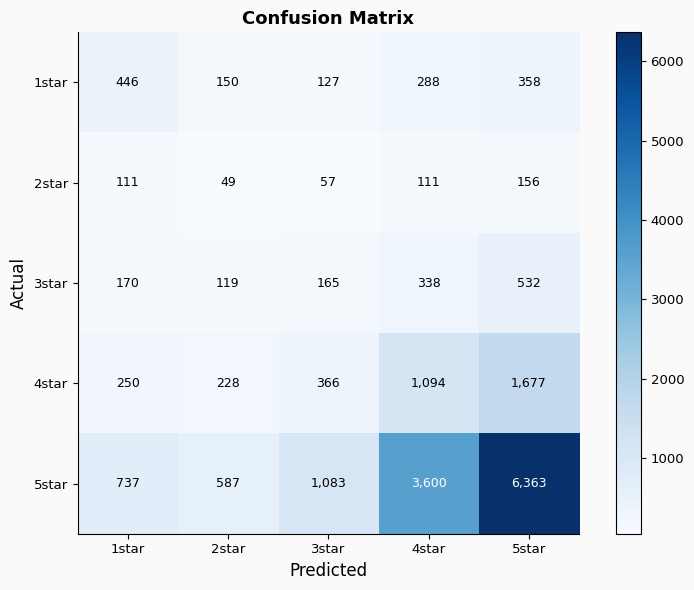

In [ ]:
cm = confusion_matrix(y_test, y_pred, labels=[1,2,3,4,5])
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im)
ax.set_xticks([0,1,2,3,4])
ax.set_yticks([0,1,2,3,4])
ax.set_xticklabels(['1star','2star','3star','4star','5star'])
ax.set_yticklabels(['1star','2star','3star','4star','5star'])
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Confusion Matrix', fontsize=13)
for i in range(5):
    for j in range(5):
        ax.text(j, i, f'{cm[i,j]:,}',
                ha='center', va='center',
                color='white' if cm[i,j] > cm.max()/2 else 'black',
                fontsize=9)
plt.tight_layout()
plt.savefig(SAVE_PATH + 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

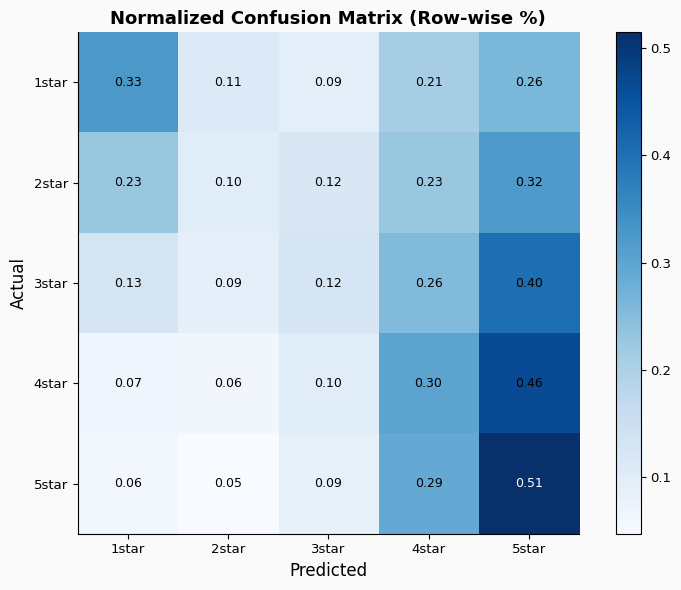

In [ ]:
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm_norm, cmap='Blues')
plt.colorbar(im)

ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels(['1star','2star','3star','4star','5star'])
ax.set_yticklabels(['1star','2star','3star','4star','5star'])

ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Normalized Confusion Matrix (Row-wise %)', fontsize=13)

for i in range(5):
    for j in range(5):
        ax.text(j, i, f'{cm_norm[i,j]:.2f}',
                ha='center', va='center',
                color='white' if cm_norm[i,j] > 0.5 else 'black',
                fontsize=9)

plt.tight_layout()
plt.savefig(SAVE_PATH + 'confusion_matrix_normalized.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
importance_df = pd.DataFrame({
    'feature'   : feature_cols,
    'importance': xgb_final.feature_importances_
}).sort_values('importance', ascending=False)

print("TOP 10 FEATURE IMPORTANCE:")
seller_feats = ['seller_avg_score','seller_late_rate',
                'seller_avg_gap','seller_order_volume']
for _, row in importance_df.head(10).iterrows():
    bar  = '|' * int(row['importance'] * 100)
    flag = ' ← NEW seller feature' if row['feature'] in seller_feats else ''
    print(f"  {row['feature']:<28} {row['importance']:.4f}  {bar}{flag}")

TOP 10 FEATURE IMPORTANCE:
  trust_gap_days               0.2068  ||||||||||||||||||||
  item_count                   0.1397  |||||||||||||
  actual_delivery_days         0.0774  |||||||
  seller_avg_score             0.0624  |||||| ← NEW seller feature
  pay_debit_card               0.0304  |||
  seller_order_volume          0.0267  || ← NEW seller feature
  freight_ratio                0.0264  ||
  total_freight                0.0264  ||
  payment_value                0.0263  ||
  total_price                  0.0262  ||


In [ ]:
seller_rank = importance_df[importance_df['feature'].isin(seller_feats)]
print(f"SELLER FEATURE RANKS:")
print(seller_rank[['feature','importance']].to_string(index=False))

SELLER FEATURE RANKS:
            feature  importance
   seller_avg_score    0.062355
seller_order_volume    0.026696
   seller_late_rate    0.026224
     seller_avg_gap    0.024977


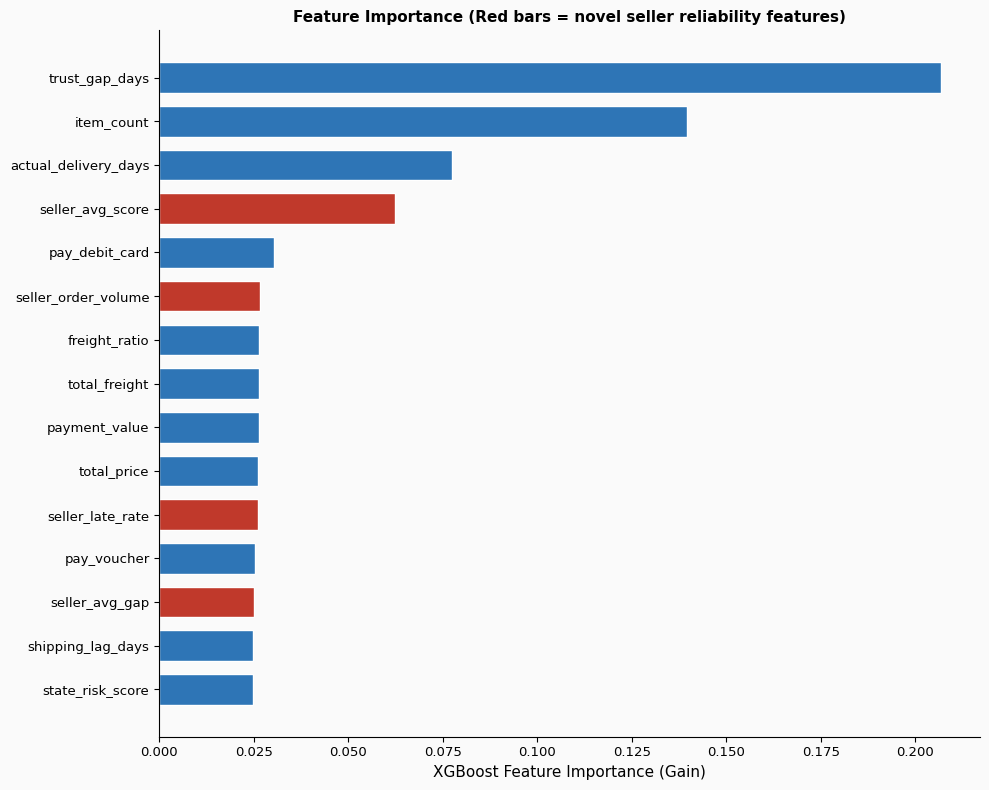

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
top15   = importance_df.head(15)
colors  = ['#C0392B' if f in seller_feats else '#2E75B6' for f in top15['feature']]
ax.barh(top15['feature'], top15['importance'],
        color=colors, edgecolor='white', height=0.7)
ax.set_xlabel('XGBoost Feature Importance (Gain)')
ax.set_title('Feature Importance (Red bars = novel seller reliability features)', fontsize=11)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(SAVE_PATH + 'feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## MODEL EXPLAINABILITY: SHAP

In [ ]:
np.random.seed(42)
sample_idx    = np.random.choice(len(X_test), 2000, replace=False)
X_shap        = X_test[sample_idx]
y_shap        = y_test[sample_idx]

In [ ]:
print(f"SHAP sample: {len(X_shap):,} test orders")
print(f"Class distribution in sample:")
for cls in sorted(np.unique(y_shap)):
    count = (y_shap == cls).sum()
    print(f"  {cls}star: {count}")

SHAP sample: 2,000 test orders
Class distribution in sample:
  1star: 152
  2star: 53
  3star: 139
  4star: 387
  5star: 1269


In [ ]:
explainer = shap.TreeExplainer(xgb_final)
shap_values = explainer.shap_values(X_shap)

print(f"\nSHAP output type: {type(shap_values)}")


SHAP output type: <class 'numpy.ndarray'>


In [ ]:
if isinstance(shap_values, list):
    print(f"Format: list of {len(shap_values)} arrays (one per class)")
    print(f"Each array shape: {shap_values[0].shape}")
    shap_1star  = shap_values[0]   # class index 0 = review_score 1
    shap_5star  = shap_values[4]   # class index 4 = review_score 5
    # Global: mean absolute SHAP across all classes
    shap_global = np.abs(np.array(shap_values)).mean(axis=0)
else:
    print(f"Format: 3D array {shap_values.shape}")
    shap_1star  = shap_values[:, :, 0]
    shap_5star  = shap_values[:, :, 4]
    shap_global = np.abs(shap_values).mean(axis=2)

print(f"shap_1star shape: {shap_1star.shape}")
print(f"shap_global shape: {shap_global.shape}")

Format: 3D array (2000, 25, 5)
shap_1star shape: (2000, 25)
shap_global shape: (2000, 25)


In [ ]:
mean_abs_shap = pd.DataFrame({
    'feature'   : feature_cols,
    'shap_importance': np.abs(shap_global).mean(axis=0)
}).sort_values('shap_importance', ascending=False)

In [ ]:
seller_feats = ['seller_avg_score','seller_late_rate', 'seller_avg_gap','seller_order_volume']

In [ ]:
for _, row in mean_abs_shap.iterrows():
    bar  = '|' * int(row['shap_importance'] * 400)
    flag = ' ← SELLER FEATURE' if row['feature'] in seller_feats else ''
    print(f"  {row['feature']:<28} {row['shap_importance']:.4f}  {flag}")

  seller_avg_score             0.1555   ← SELLER FEATURE
  trust_gap_days               0.1089  
  item_count                   0.0691  
  actual_delivery_days         0.0611  
  seller_order_volume          0.0548   ← SELLER FEATURE
  seller_late_rate             0.0225   ← SELLER FEATURE
  total_freight                0.0167  
  seller_avg_gap               0.0129   ← SELLER FEATURE
  freight_ratio                0.0098  
  category_risk_score          0.0089  
  payment_value                0.0083  
  shipping_lag_days            0.0072  
  promised_delivery_days       0.0071  
  total_price                  0.0059  
  product_length_cm            0.0058  
  product_height_cm            0.0056  
  payment_installments         0.0056  
  state_risk_score             0.0053  
  product_width_cm             0.0047  
  product_weight_g             0.0047  
  approval_lag_days            0.0016  
  pay_credit_card              0.0015  
  same_state                   0.0009  
  pay_vouche

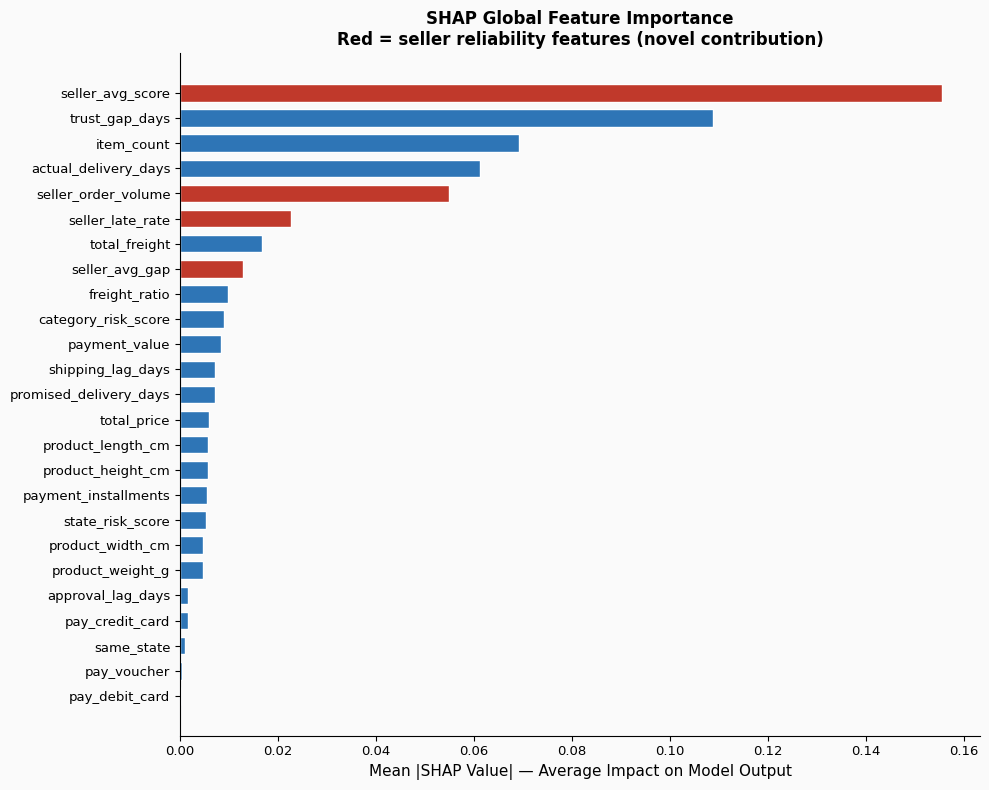

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#C0392B' if f in seller_feats else '#2E75B6'
          for f in mean_abs_shap['feature']]
ax.barh(mean_abs_shap['feature'],
        mean_abs_shap['shap_importance'],
        color=colors, edgecolor='white', height=0.7)
ax.set_xlabel('Mean |SHAP Value| — Average Impact on Model Output', fontsize=11)
ax.set_title('SHAP Global Feature Importance\n'
             'Red = seller reliability features (novel contribution)',
             fontsize=12)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(SAVE_PATH + 'shap_global_importance.png', dpi=150, bbox_inches='tight')
plt.show()

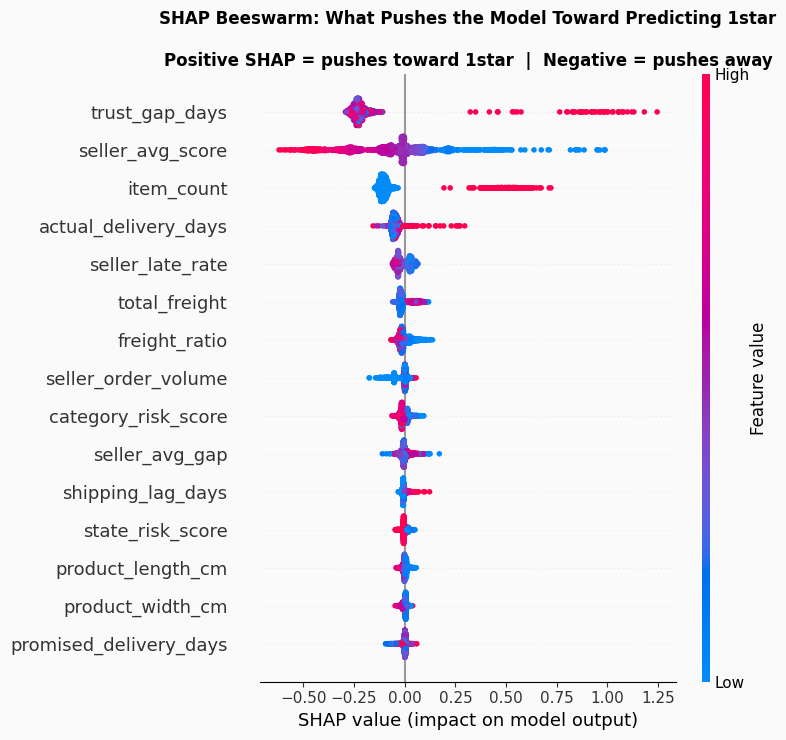

In [ ]:
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_1star,
    X_shap,
    feature_names=feature_cols,
    max_display=15,
    show=False,
    plot_type='dot'
)
plt.title('SHAP Beeswarm: What Pushes the Model Toward Predicting 1star\n\n'
          'Positive SHAP = pushes toward 1star  |  Negative = pushes away',
          fontsize=12)
plt.tight_layout()
plt.savefig(SAVE_PATH + 'shap_beeswarm_1star.png', dpi=150, bbox_inches='tight')
plt.show()

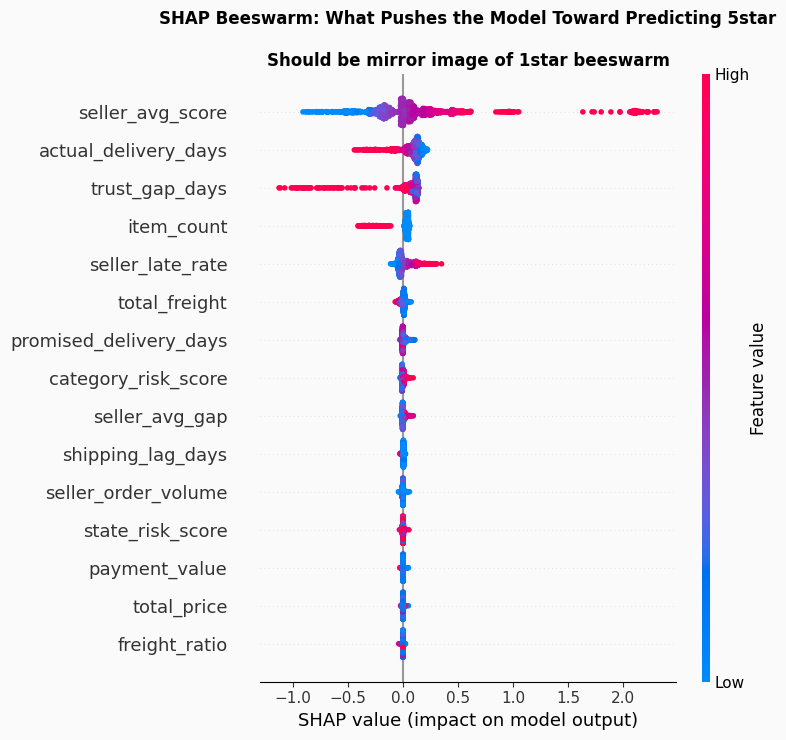

In [ ]:
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_5star,
    X_shap,
    feature_names=feature_cols,
    max_display=15,
    show=False,
    plot_type='dot'
)
plt.title('SHAP Beeswarm: What Pushes the Model Toward Predicting 5star\n\n'
          'Should be mirror image of 1star beeswarm',
          fontsize=12)
plt.tight_layout()
plt.savefig(SAVE_PATH + 'shap_beeswarm_5star.png', dpi=150, bbox_inches='tight')
plt.show()

  Found 152 actual 1-star orders in sample


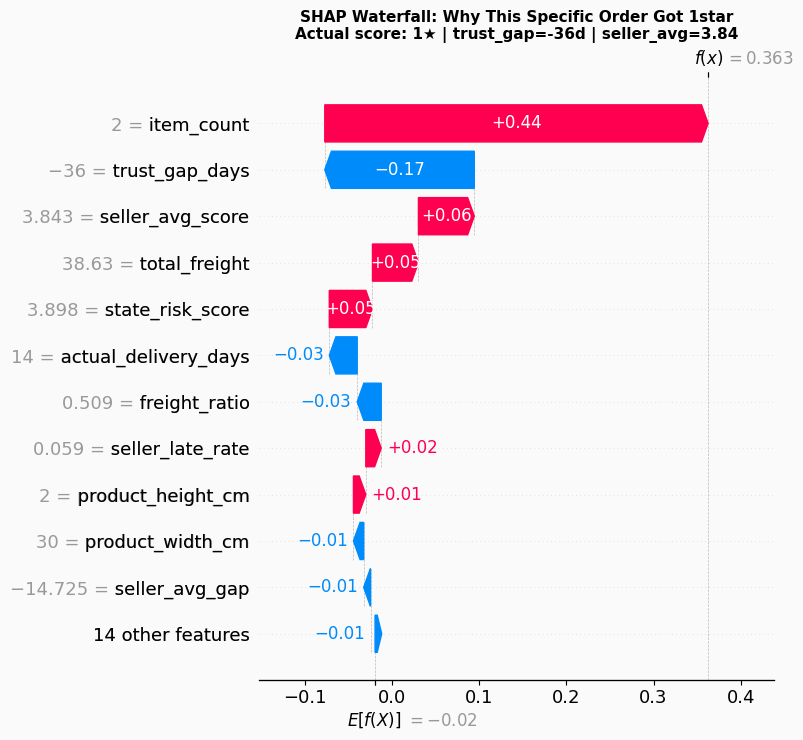

This order details:
    trust_gap_days:       -36.0
    actual_delivery_days: 14.0
    seller_avg_score:     3.843
    item_count:           2


In [ ]:
idx_1star = np.where(y_shap == 1)[0]
print(f"  Found {len(idx_1star)} actual 1-star orders in sample")

if len(idx_1star) > 0:
    order_idx = idx_1star[0]

    base_val = explainer.expected_value
    if isinstance(base_val, (list, np.ndarray)):
        base_val = float(base_val[0])

    explanation = shap.Explanation(
        values        = shap_1star[order_idx],
        base_values   = base_val,
        data          = X_shap[order_idx],
        feature_names = feature_cols
    )

    plt.figure(figsize=(12, 7))
    shap.waterfall_plot(explanation, max_display=12, show=False)
    plt.title(f'SHAP Waterfall: Why This Specific Order Got 1star\n'
              f'Actual score: {y_shap[order_idx]}★ | '
              f'trust_gap={X_shap[order_idx][feature_cols.index("trust_gap_days")]:.0f}d | '
              f'seller_avg={X_shap[order_idx][feature_cols.index("seller_avg_score")]:.2f}',
              fontsize=11)
    plt.tight_layout()
    plt.savefig(SAVE_PATH + 'shap_waterfall_1star.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"This order details:")
    print(f"    trust_gap_days:       {X_shap[order_idx][feature_cols.index('trust_gap_days')]:.1f}")
    print(f"    actual_delivery_days: {X_shap[order_idx][feature_cols.index('actual_delivery_days')]:.1f}")
    print(f"    seller_avg_score:     {X_shap[order_idx][feature_cols.index('seller_avg_score')]:.3f}")
    print(f"    item_count:           {X_shap[order_idx][feature_cols.index('item_count')]:.0f}")

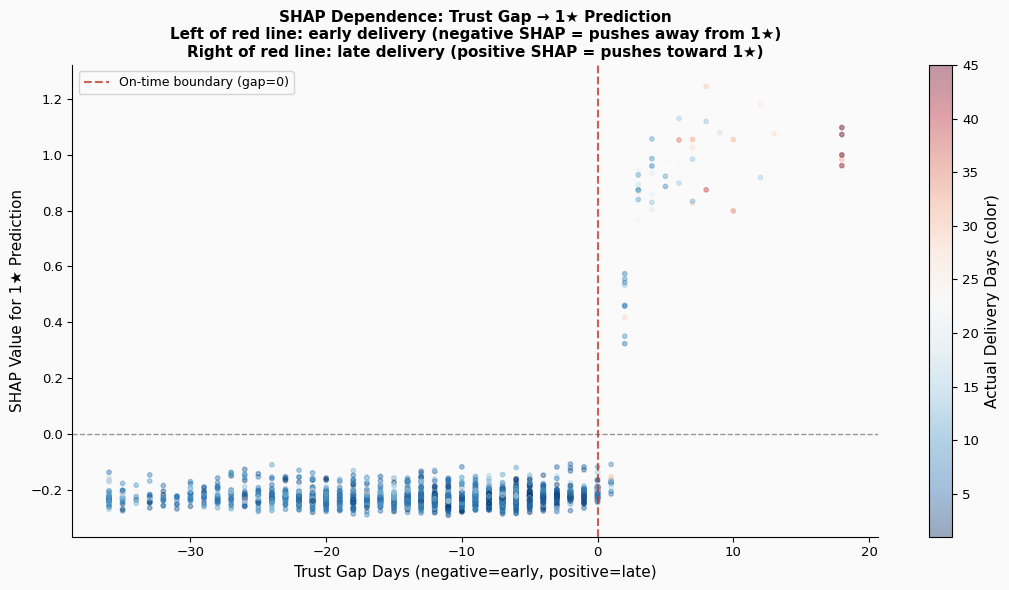

In [ ]:
tg_idx  = feature_cols.index('trust_gap_days')
del_idx = feature_cols.index('actual_delivery_days')

fig, ax = plt.subplots(figsize=(11, 6))
sc = ax.scatter(
    X_shap[:, tg_idx],
    shap_1star[:, tg_idx],
    c=X_shap[:, del_idx],
    cmap='RdBu_r',
    alpha=0.4,
    s=10
)
plt.colorbar(sc, label='Actual Delivery Days (color)')
ax.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.4)
ax.axvline(0, color='#C0392B', linewidth=1.5, linestyle='--',
           alpha=0.8, label='On-time boundary (gap=0)')
ax.set_xlabel('Trust Gap Days (negative=early, positive=late)', fontsize=11)
ax.set_ylabel('SHAP Value for 1★ Prediction', fontsize=11)
ax.set_title('SHAP Dependence: Trust Gap → 1★ Prediction\n'
             'Left of red line: early delivery (negative SHAP = pushes away from 1★)\n'
             'Right of red line: late delivery (positive SHAP = pushes toward 1★)',
             fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(SAVE_PATH + 'shap_dependence_trustgap.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
print(f"Top 5 features by global SHAP importance:")
for i, (_, row) in enumerate(mean_abs_shap.head(5).iterrows(), 1):
    flag = ' ← SELLER' if row['feature'] in seller_feats else ''
    print(f"  {i}. {row['feature']:<28} {row['shap_importance']:.4f}{flag}")

Top 5 features by global SHAP importance:
  1. seller_avg_score             0.1555 ← SELLER
  2. trust_gap_days               0.1089
  3. item_count                   0.0691
  4. actual_delivery_days         0.0611
  5. seller_order_volume          0.0548 ← SELLER


In [ ]:
print(f"Seller features combined SHAP importance:")
seller_total = mean_abs_shap[mean_abs_shap['feature'].isin(seller_feats)]['shap_importance'].sum()
delivery_total = mean_abs_shap[mean_abs_shap['feature'].isin(['trust_gap_days','actual_delivery_days'])]['shap_importance'].sum()
print(f"  All 4 seller features:         {seller_total:.4f}")
print(f"  Two core delivery features:    {delivery_total:.4f}")
print(f"  Seller features are {'MORE' if seller_total > delivery_total else 'LESS'} important than delivery features combined")

Seller features combined SHAP importance:
  All 4 seller features:         0.2457
  Two core delivery features:    0.1700
  Seller features are MORE important than delivery features combined


In [ ]:
X_test_full  = test_df[feature_cols].astype(float).values
y_test_full  = test_df['review_score'].values

In [ ]:
y_pred_full  = xgb_final.predict(X_test_full) + 1

overall_f1 = f1_score(y_test_full, y_pred_full, average='macro')
overall_acc = accuracy_score(y_test_full, y_pred_full)

In [ ]:
print(f"Full test set: {len(test_df):,} orders")
print(f"Overall macro F1: {overall_f1:.4f}")
print(f"Overall accuracy: {overall_acc:.4f}")
print(f"Any group with F1 gap < -0.05 is flagged as BIASED")

Full test set: 19,162 orders
Overall macro F1: 0.2581
Overall accuracy: 0.4236
Any group with F1 gap < -0.05 is flagged as BIASED


## BIAS ANALYSIS

In [ ]:
print("BIAS ANALYSIS: GEOGRAPHIC (by customer state)\n")
print(f"{'State':<8} {'Orders':>7} {'Macro F1':>10} {'vs National':>12} "f"{'Late%':>7} {'Flag':>12}")

state_bias = []
for state in sorted(test_df['customer_state'].unique()):
    mask  = (test_df['customer_state'] == state).values
    count = mask.sum()
    if count < 30:
        continue

    f1   = f1_score(y_test_full[mask], y_pred_full[mask],
                    average='macro', zero_division=0)
    diff = f1 - overall_f1
    late = (test_df.loc[test_df['customer_state']==state, 'trust_gap_days'] > 0).mean() * 100
    flag = 'BIASED' if diff < -0.05 else ('OK' if diff >= 0 else 'below')

    state_bias.append({'state': state, 'orders': count,
                       'f1': f1, 'diff': diff,
                       'late_rate': late, 'flag': flag})
    print(f"  {state:<6} {count:>7,}   {f1:>10.4f}   {diff:>+11.4f}  "
          f"   {late:>6.1f}%    ->      {flag}")

state_bias_df = pd.DataFrame(state_bias).sort_values('f1')

BIAS ANALYSIS: GEOGRAPHIC (by customer state)

State     Orders   Macro F1  vs National   Late%         Flag
  AL          65       0.2115       -0.0466        6.2%    ->      below
  AM          30       0.2869       +0.0288        0.0%    ->      OK
  BA         634       0.2692       +0.0110        3.9%    ->      OK
  CE         215       0.2285       -0.0296        0.5%    ->      below
  DF         466       0.2892       +0.0310        2.8%    ->      OK
  ES         358       0.2740       +0.0158        3.6%    ->      OK
  GO         346       0.2393       -0.0189        2.6%    ->      below
  MA         115       0.2877       +0.0295       12.2%    ->      OK
  MG       2,118       0.2595       +0.0014        1.0%    ->      OK
  MS         136       0.2554       -0.0027        9.6%    ->      below
  MT         150       0.2407       -0.0174        0.7%    ->      below
  PA         159       0.2885       +0.0304        1.9%    ->      OK
  PB         113       0.2234       

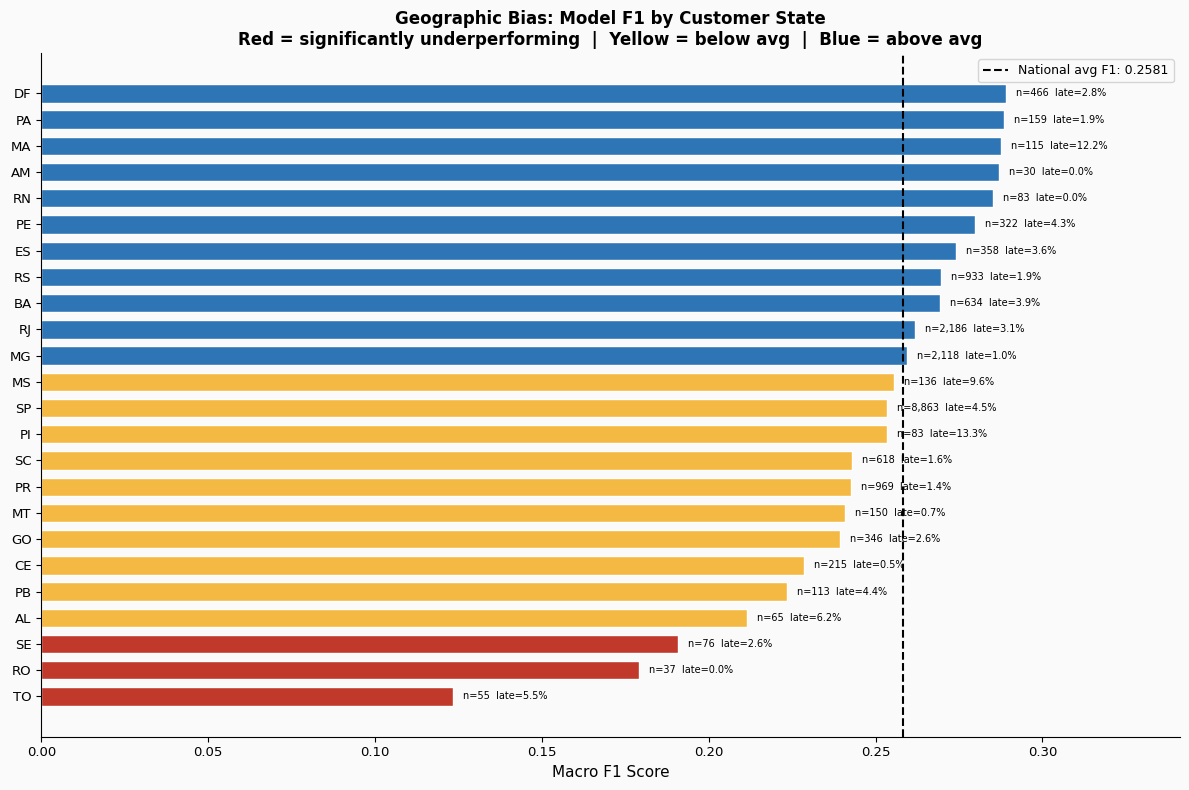

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#C0392B' if d < -0.05 else '#F4B942' if d < 0
          else '#2E75B6' for d in state_bias_df['diff']]
bars = ax.barh(state_bias_df['state'], state_bias_df['f1'],
               color=colors, height=0.7, edgecolor='white')
ax.axvline(overall_f1, color='black', linestyle='--', linewidth=1.5,
           label=f'National avg F1: {overall_f1:.4f}')
ax.set_xlabel('Macro F1 Score', fontsize=11)
ax.set_title('Geographic Bias: Model F1 by Customer State\n'
             'Red = significantly underperforming  |  '
             'Yellow = below avg  |  Blue = above avg', fontsize=12)
ax.legend(fontsize=9)
ax.set_xlim(0, state_bias_df['f1'].max() * 1.18)
for bar, (_, row) in zip(bars, state_bias_df.iterrows()):
    ax.text(bar.get_width() + 0.003,
            bar.get_y() + bar.get_height()/2,
            f"n={row['orders']:,}  late={row['late_rate']:.1f}%",
            va='center', fontsize=7)
plt.tight_layout()
plt.savefig(SAVE_PATH + 'bias_geographic.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
biased_states = state_bias_df[state_bias_df['diff'] < -0.05]
print(f"GEOGRAPHIC BIAS SUMMARY:")
print(f"  Total states evaluated:           {len(state_bias_df)}")
print(f"  States significantly biased:      {len(biased_states)}")
print(f"  Best state:  {state_bias_df.iloc[-1]['state']} "
      f"F1={state_bias_df.iloc[-1]['f1']:.4f}")
print(f"  Worst state: {state_bias_df.iloc[0]['state']} "
      f"F1={state_bias_df.iloc[0]['f1']:.4f}")
print(f"  F1 range:    {state_bias_df['f1'].max()-state_bias_df['f1'].min():.4f}")
if len(biased_states) > 0:
    print(f"\n Significantly biased states:")
    for _, row in biased_states.iterrows():
        print(f"    {row['state']}: F1={row['f1']:.4f} "
              f"(gap={row['diff']:+.4f}, n={row['orders']:,}, "
              f"late={row['late_rate']:.1f}%)")

GEOGRAPHIC BIAS SUMMARY:
  Total states evaluated:           24
  States significantly biased:      3
  Best state:  DF F1=0.2892
  Worst state: TO F1=0.1235
  F1 range:    0.1657

 Significantly biased states:
    TO: F1=0.1235 (gap=-0.1346, n=55, late=5.5%)
    RO: F1=0.1790 (gap=-0.0791, n=37, late=0.0%)
    SE: F1=0.1907 (gap=-0.0674, n=76, late=2.6%)


In [ ]:
cat_bias = []
for cat in sorted(test_df['product_category_name_english'].unique()):
    mask  = (test_df['product_category_name_english'] == cat).values
    count = mask.sum()
    if count < 50:
        continue

    f1   = f1_score(y_test_full[mask], y_pred_full[mask],
                    average='macro', zero_division=0)
    diff = f1 - overall_f1
    flag = 'BIASED' if diff < -0.05 else '△ below' if diff < 0 else '✓ OK'
    cat_bias.append({'category': cat, 'orders': count,
                     'f1': f1, 'diff': diff, 'flag': flag})

cat_bias_df = pd.DataFrame(cat_bias).sort_values('f1')

In [ ]:
print(f"{'Category':<38} {'n':>6} {'F1':>8} {'Gap':>8} {'Flag':>10}")
print("-"*72)
for _, row in cat_bias_df[abs(cat_bias_df['diff']) > 0.03].iterrows():
    print(f"  {row['category'][:36]:<38} {row['orders']:>6,} "
          f"{row['f1']:>8.4f} {row['diff']:>+7.4f}  {row['flag']}")

Category                                    n       F1      Gap       Flag
------------------------------------------------------------------------
  signaling_and_security                     53   0.1444 -0.1137  BIASED
  audio                                      65   0.1537 -0.1045  BIASED
  furniture_living_room                     115   0.1541 -0.1040  BIASED
  books_technical                            82   0.1574 -0.1007  BIASED
  office_furniture                          151   0.1869 -0.0713  BIASED
  unknown                                    90   0.1890 -0.0692  BIASED
  small_appliances                          104   0.2004 -0.0577  BIASED
  construction_tools_safety                  51   0.2025 -0.0556  BIASED
  agro_industry_and_commerce                 51   0.2132 -0.0449  △ below
  construction_tools_lights                 128   0.2169 -0.0413  △ below
  telephony                                 667   0.2169 -0.0412  △ below
  bed_bath_table                          1,75

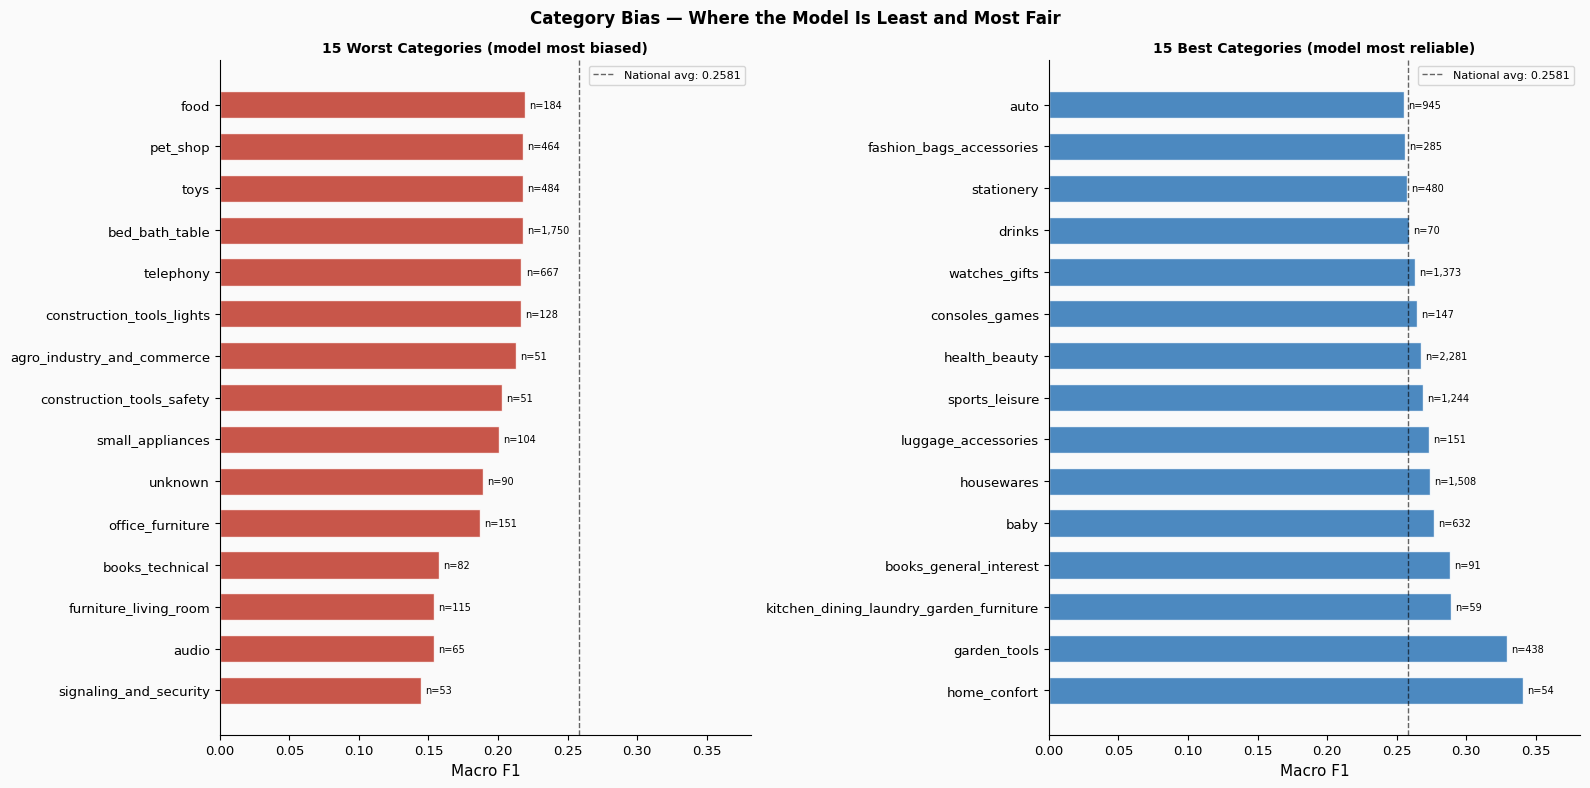

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
worst15 = cat_bias_df.head(15)
best15  = cat_bias_df.tail(15).sort_values('f1', ascending=False)

for ax, data, title, color in [
    (axes[0], worst15, '15 Worst Categories (model most biased)', '#C0392B'),
    (axes[1], best15,  '15 Best Categories (model most reliable)', '#2E75B6')
]:
    ax.barh(data['category'], data['f1'],
            color=color, height=0.65, edgecolor='white', alpha=0.85)
    ax.axvline(overall_f1, color='black', linestyle='--',
               linewidth=1, alpha=0.6,
               label=f'National avg: {overall_f1:.4f}')
    ax.set_xlabel('Macro F1')
    ax.set_title(title, fontsize=10)
    ax.set_xlim(0, cat_bias_df['f1'].max() * 1.12)
    ax.legend(fontsize=8)
    for bar, (_, row) in zip(ax.patches, data.iterrows()):
        ax.text(bar.get_width() + 0.003,
                bar.get_y() + bar.get_height()/2,
                f"n={row['orders']:,}", va='center', fontsize=7)

plt.suptitle('Category Bias — Where the Model Is Least and Most Fair',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_PATH + 'bias_category.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
biased_cats = cat_bias_df[cat_bias_df['diff'] < -0.05]
print(f"CATEGORY BIAS SUMMARY:\n")
print(f"  Total categories evaluated:       {len(cat_bias_df)}")
print(f"  Categories significantly biased:  {len(biased_cats)}")
if len(biased_cats) > 0:
    print(f"  Top biased categories:")
    for _, row in biased_cats.head(8).iterrows():
        print(f"    {row['category'][:40]}: "
              f"F1={row['f1']:.4f} (gap={row['diff']:+.4f})")

CATEGORY BIAS SUMMARY:

  Total categories evaluated:       41
  Categories significantly biased:  8
  Top biased categories:
    signaling_and_security: F1=0.1444 (gap=-0.1137)
    audio: F1=0.1537 (gap=-0.1045)
    furniture_living_room: F1=0.1541 (gap=-0.1040)
    books_technical: F1=0.1574 (gap=-0.1007)
    office_furniture: F1=0.1869 (gap=-0.0713)
    unknown: F1=0.1890 (gap=-0.0692)
    small_appliances: F1=0.2004 (gap=-0.0577)
    construction_tools_safety: F1=0.2025 (gap=-0.0556)


In [ ]:
for flag, label in [(1, 'Same State'), (0, 'Different State')]:
    mask  = (test_df['same_state'] == flag).values
    count = mask.sum()
    f1    = f1_score(y_test_full[mask], y_pred_full[mask],
                     average='macro', zero_division=0)
    acc   = accuracy_score(y_test_full[mask], y_pred_full[mask])
    diff  = f1 - overall_f1
    per   = f1_score(y_test_full[mask], y_pred_full[mask],
                     average=None, labels=[1,2,3,4,5], zero_division=0)

    print(f"\n  {label} ({count:,} orders):")
    print(f"    Macro F1:  {f1:.4f}  ({diff:+.4f} vs national)")
    print(f"    Accuracy:  {acc:.4f}")
    print(f"    Per-class F1:")
    for cls, fv in zip([1,2,3,4,5], per):
        bar = '|' * int(fv * 20)
        print(f"      {cls}star: {fv:.4f}  {bar}")


  Same State (7,742 orders):
    Macro F1:  0.2532  (-0.0049 vs national)
    Accuracy:  0.4359
    Per-class F1:
      1star: 0.2582  |||||
      2star: 0.0615  |
      3star: 0.1059  ||
      4star: 0.2237  ||||
      5star: 0.6167  ||||||||||||

  Different State (11,420 orders):
    Macro F1:  0.2606  (+0.0025 vs national)
    Accuracy:  0.4152
    Per-class F1:
      1star: 0.3087  ||||||
      2star: 0.0599  |
      3star: 0.1055  ||
      4star: 0.2526  |||||
      5star: 0.5763  |||||||||||


In [ ]:
print("FAIRNESS SUMMARY TABLE")
print(f"  National macro F1:               {overall_f1:.4f}")
print(f"  Best state F1:    "
      f"{state_bias_df.iloc[-1]['f1']:.4f}  "
      f"({state_bias_df.iloc[-1]['state']})")
print(f"  Worst state F1:   "
      f"{state_bias_df.iloc[0]['f1']:.4f}  "
      f"({state_bias_df.iloc[0]['state']})")
print(f"  F1 disparity (state range):      "
      f"{state_bias_df['f1'].max()-state_bias_df['f1'].min():.4f}")
print(f"  States significantly biased:     {len(biased_states)}")
print(f"  Categories significantly biased: {len(biased_cats)}")

FAIRNESS SUMMARY TABLE
  National macro F1:               0.2581
  Best state F1:    0.2892  (DF)
  Worst state F1:   0.1235  (TO)
  F1 disparity (state range):      0.1657
  States significantly biased:     3
  Categories significantly biased: 8


In [ ]:
X_train_arr = train_df[feature_cols].astype(float).values
y_train_arr = train_df['review_score'].values
X_test_arr  = test_df[feature_cols].astype(float).values
y_test_arr  = test_df['review_score'].values

overall_f1 = f1_score(
    y_test_arr,
    xgb_final.predict(X_test_arr) + 1,
    average='macro'
)
print(f"Baseline test macro F1: {overall_f1:.4f}")

Baseline test macro F1: 0.2581


In [ ]:
BIASED_STATES = ['TO', 'SE']
BIASED_CATS   = [
    'furniture_living_room', 'audio', 'books_technical',
    'unknown', 'signaling_and_security', 'small_appliances',
    'agro_industry_and_commerce', 'office_furniture', 'art'
]
BOOST = 2.0

base_weights = compute_sample_weight('balanced', y=y_train_arr - 1)
geo_boost    = np.where(train_df['customer_state'].isin(BIASED_STATES), BOOST, 1.0)
cat_boost    = np.where(
    train_df['product_category_name_english'].isin(BIASED_CATS), BOOST, 1.0)
combined_w   = base_weights * geo_boost * cat_boost

print(f"\nBias mitigation: upweighting {BIASED_STATES} states and {len(BIASED_CATS)} categories")
print(f"BOOST factor: {BOOST}x")
print(f"Boosted samples: {(combined_w > base_weights.mean()).sum():,}")


Bias mitigation: upweighting ['TO', 'SE'] states and 9 categories
BOOST factor: 2.0x
Boosted samples: 32,276


In [ ]:
xgb_fair = xgb.XGBClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    min_child_weight=5, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0, eval_metric='mlogloss',
    random_state=42, n_jobs=-1, verbosity=0, early_stopping_rounds=30
)

In [ ]:
xgb_fair.fit(
    X_train_arr, y_train_arr - 1,
    sample_weight=combined_w,
    eval_set=[(X_test_arr, y_test_arr - 1)],
    verbose=False
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=30,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=5, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=-1,
              num_parallel_tree=None, ...)

In [ ]:
y_pred_fair = xgb_fair.predict(X_test_arr) + 1
f1_fair     = f1_score(y_test_arr, y_pred_fair, average='macro')

In [ ]:
print(f"MITIGATION RESULT:")
print(f"  Original F1:  {overall_f1:.4f}")
print(f"  Mitigated F1: {f1_fair:.4f}")
print(f"  Change:       {f1_fair - overall_f1:+.4f}")

MITIGATION RESULT:
  Original F1:  0.2581
  Mitigated F1: 0.2571
  Change:       -0.0010


In [ ]:
print(f"\n{'State':<8} {'F1 Before':>10} {'F1 After':>10} {'Change':>8} {'Status':>12}")
print("-"*52)
improved = regressed = unchanged = 0
for state in sorted(test_df['customer_state'].unique()):
    mask  = (test_df['customer_state'] == state).values
    count = mask.sum()
    if count < 30:
        continue
    f1_b = f1_score(y_test_arr[mask], xgb_final.predict(X_test_arr[mask])+1,
                    average='macro', zero_division=0)
    f1_a = f1_score(y_test_arr[mask], y_pred_fair[mask],
                    average='macro', zero_division=0)
    delta = f1_a - f1_b
    status = 'improved' if delta > 0.01 else 'regressed' if delta < -0.01 else 'unchanged'
    if delta > 0.01: improved += 1
    elif delta < -0.01: regressed += 1
    else: unchanged += 1
    flag = '-> was biased' if state in BIASED_STATES else ''
    print(f"  {state:<6} {f1_b:>10.4f}   {f1_a:>10.4f}   {delta:>+7.4f}     {status}    {flag}")


State     F1 Before   F1 After   Change       Status
----------------------------------------------------
  AL         0.2115       0.2319   +0.0203     improved    
  AM         0.2869       0.3032   +0.0163     improved    
  BA         0.2692       0.2589   -0.0103     regressed    
  CE         0.2285       0.2285   -0.0000     unchanged    
  DF         0.2892       0.2948   +0.0057     unchanged    
  ES         0.2740       0.2626   -0.0114     regressed    
  GO         0.2393       0.2462   +0.0070     unchanged    
  MA         0.2877       0.3559   +0.0682     improved    
  MG         0.2595       0.2625   +0.0030     unchanged    
  MS         0.2554       0.2300   -0.0255     regressed    
  MT         0.2407       0.2144   -0.0263     regressed    
  PA         0.2885       0.2877   -0.0008     unchanged    
  PB         0.2234       0.2860   +0.0626     improved    
  PE         0.2797       0.2853   +0.0056     unchanged    
  PI         0.2533       0.2741   +0.0208 

In [ ]:
state_f1_before = []
state_f1_after  = []
for state in sorted(test_df['customer_state'].unique()):
    mask = (test_df['customer_state'] == state).values
    if mask.sum() < 30: continue
    state_f1_before.append(
        f1_score(y_test_arr[mask], xgb_final.predict(X_test_arr[mask])+1,
                 average='macro', zero_division=0))
    state_f1_after.append(
        f1_score(y_test_arr[mask], y_pred_fair[mask],
                 average='macro', zero_division=0))

disp_before = max(state_f1_before) - min(state_f1_before)
disp_after  = max(state_f1_after)  - min(state_f1_after)

In [ ]:
print(f"  States improved:  {improved}")
print(f"  States unchanged: {unchanged}")
print(f"  States regressed: {regressed}")
print(f"  F1 disparity before: {disp_before:.4f}")
print(f"  F1 disparity after:  {disp_after:.4f}")


  States improved:  10
  States unchanged: 8
  States regressed: 6
  F1 disparity before: 0.1657
  F1 disparity after:  0.2310


In [ ]:
if disp_after < disp_before and f1_fair >= overall_f1 - 0.005:
    deploy_model = xgb_fair
    deploy_name  = "xgb_fair"
    print(f"DECISION: Deploy xgb_fair (mitigation improved fairness)")
else:
    deploy_model = xgb_final
    deploy_name  = "xgb_final"
    print(f"DECISION: Deploy xgb_final (mitigation did not improve fairness)")

DECISION: Deploy xgb_final (mitigation did not improve fairness)


## MODEL PACKAGING & DEPLOYMENT

In [ ]:
os.makedirs(SAVE_PATH + 'model_package/', exist_ok=True)

In [ ]:
deploy_model.save_model(
    SAVE_PATH + f'model_package/{deploy_name}_model.json'
)
print(f"  Model saved: {deploy_name}_model.json")

  Model saved: xgb_final_model.json


In [ ]:
f1_per = f1_score(y_test_arr, deploy_model.predict(X_test_arr)+1,
                  average=None, labels=[1,2,3,4,5])

In [ ]:
metadata = {
    'model_name'       : deploy_name,
    'model_type'       : 'XGBoostClassifier',
    'n_features'       : len(feature_cols),
    'feature_cols'     : feature_cols,
    'target'           : 'review_score',
    'classes'          : [1, 2, 3, 4, 5],
    'test_macro_f1'    : round(float(f1_score(y_test_arr,
                          deploy_model.predict(X_test_arr)+1,
                          average='macro')), 4),
    'test_accuracy'    : round(float(accuracy_score(
                          y_test_arr,
                          deploy_model.predict(X_test_arr)+1)), 4),
    'per_class_f1'     : {f'{i+1}_star': round(float(v), 4)
                          for i, v in enumerate(f1_per)},
    'baseline_macro_f1': 0.1569,
    'improvement_vs_baseline': round(float(f1_score(
        y_test_arr, deploy_model.predict(X_test_arr)+1,
        average='macro')) - 0.1569, 4),
    'train_date_range' : '2016-10-03 to 2018-05-27',
    'test_date_range'  : '2018-05-27 to 2018-08-29',
}

In [ ]:
with open(SAVE_PATH + 'model_package/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"  Metadata saved: model_metadata.json")

  Metadata saved: model_metadata.json


In [ ]:
encoding_maps = {
    'state_risk_score'   : state_encode.to_dict(),
    'category_risk_score': category_encode.to_dict(),
    'global_avg_score'   : float(global_avg_score)
}
with open(SAVE_PATH + 'model_package/encoding_maps.json', 'w') as f:
    json.dump(encoding_maps, f, indent=2)
print(f"  Encoding maps saved: encoding_maps.json")

  Encoding maps saved: encoding_maps.json


In [ ]:
score_py = f'''#!/usr/bin/env python3
"""
score.py — Olist Trust Gap Model Scoring Script
Project: Delivery Promise Integrity — The Trust Gap Model
Course:  DSAI 4103 Business Analytics

Takes order features as input.
Returns predicted review score (1-5) and class probabilities.

Usage:
    python score.py
    OR: from score import predict_score
"""

import pandas as pd
import numpy as np
import xgboost as xgb
import json

MODEL_PATH    = "model_package/{deploy_name}_model.json"
METADATA_PATH = "model_package/model_metadata.json"
ENCODING_PATH = "model_package/encoding_maps.json"


def load_artifacts():
    """Load model, metadata, and encoding maps."""
    model = xgb.XGBClassifier()
    model.load_model(MODEL_PATH)
    with open(METADATA_PATH) as f:
        meta = json.load(f)
    with open(ENCODING_PATH) as f:
        enc = json.load(f)
    return model, meta, enc


def predict_score(order_dict):
    """
    Predict review score for a single order.

    Parameters
    ----------
    order_dict : dict
        Must contain these keys:
        trust_gap_days, actual_delivery_days, promised_delivery_days,
        shipping_lag_days, approval_lag_days, total_price, total_freight,
        freight_ratio, item_count, payment_installments, payment_value,
        product_weight_g, product_length_cm, product_height_cm,
        product_width_cm, same_state, customer_state,
        product_category_name_english, payment_type,
        seller_avg_score, seller_late_rate, seller_avg_gap,
        seller_order_volume

    Returns
    -------
    dict with predicted_score (int 1-5) and probabilities per class
    """
    model, meta, enc = load_artifacts()

    df = pd.DataFrame([order_dict])

    # Apply target encodings using training-set maps
    global_avg = enc["global_avg_score"]
    df["state_risk_score"]    = df["customer_state"].map(
        enc["state_risk_score"]).fillna(global_avg)
    df["category_risk_score"] = df["product_category_name_english"].map(
        enc["category_risk_score"]).fillna(global_avg)

    # Payment type dummies
    df["pay_credit_card"] = (df["payment_type"] == "credit_card").astype(float)
    df["pay_debit_card"]  = (df["payment_type"] == "debit_card").astype(float)
    df["pay_voucher"]     = (df["payment_type"] == "voucher").astype(float)

    X      = df[meta["feature_cols"]].astype(float).values
    pred   = int(model.predict(X)[0]) + 1
    proba  = model.predict_proba(X)[0]

    return {{
        "predicted_score": pred,
        "confidence"     : round(float(proba[pred - 1]), 4),
        "probabilities"  : {{
            "1_star": round(float(proba[0]), 4),
            "2_star": round(float(proba[1]), 4),
            "3_star": round(float(proba[2]), 4),
            "4_star": round(float(proba[3]), 4),
            "5_star": round(float(proba[4]), 4),
        }},
        "model_version": meta["model_name"]
    }}


if __name__ == "__main__":
    # ── Example 1: Late order from bad seller
    late_bad_seller = {{
        "trust_gap_days"                : 8,
        "actual_delivery_days"          : 25,
        "promised_delivery_days"        : 17,
        "shipping_lag_days"             : 5,
        "approval_lag_days"             : 0,
        "total_price"                   : 180.0,
        "total_freight"                 : 28.0,
        "freight_ratio"                 : 0.156,
        "item_count"                    : 1,
        "payment_installments"          : 3,
        "payment_value"                 : 208.0,
        "product_weight_g"              : 1200,
        "product_length_cm"             : 35,
        "product_height_cm"             : 20,
        "product_width_cm"              : 25,
        "same_state"                    : 0,
        "customer_state"                : "MA",
        "product_category_name_english" : "furniture_living_room",
        "payment_type"                  : "credit_card",
        "seller_avg_score"              : 3.1,
        "seller_late_rate"              : 0.25,
        "seller_avg_gap"                : 5.0,
        "seller_order_volume"           : 45
    }}

    # ── Example 2: Early order from reliable seller
    early_good_seller = {{
        "trust_gap_days"                : -10,
        "actual_delivery_days"          : 7,
        "promised_delivery_days"        : 17,
        "shipping_lag_days"             : 1,
        "approval_lag_days"             : 0,
        "total_price"                   : 95.0,
        "total_freight"                 : 14.0,
        "freight_ratio"                 : 0.147,
        "item_count"                    : 1,
        "payment_installments"          : 1,
        "payment_value"                 : 109.0,
        "product_weight_g"              : 400,
        "product_length_cm"             : 20,
        "product_height_cm"             : 10,
        "product_width_cm"              : 15,
        "same_state"                    : 1,
        "customer_state"                : "SP",
        "product_category_name_english" : "health_beauty",
        "payment_type"                  : "credit_card",
        "seller_avg_score"              : 4.7,
        "seller_late_rate"              : 0.02,
        "seller_avg_gap"                : -12.0,
        "seller_order_volume"           : 380
    }}

    print("OLIST TRUST GAP MODEL — SCORING EXAMPLES")
    print("=" * 50)

    for name, order in [("Late order, bad seller", late_bad_seller),
                         ("Early order, good seller", early_good_seller)]:
        result = predict_score(order)
        print(f"\\nExample: {{name}}")
        print(f"  Predicted score: {{result['predicted_score']}}★")
        print(f"  Confidence:      {{result['confidence']*100:.1f}}%")
        print(f"  Probabilities:   {{result['probabilities']}}")
'''

with open(SAVE_PATH + 'model_package/score.py', 'w') as f:
    f.write(score_py)
print(f"  Scoring script saved: score.py")

  Scoring script saved: score.py


## SUMMARY

In [ ]:
final_f1 = f1_score(y_test_arr, deploy_model.predict(X_test_arr)+1,  average='macro')
final_acc = accuracy_score(y_test_arr, deploy_model.predict(X_test_arr)+1)

In [ ]:
print(f"DEPLOYED MODEL:     {deploy_name}")
print(f"  Test Macro F1:      {final_f1:.4f}  " f"(+{final_f1-0.1569:.4f} vs naive baseline)")
print(f"  Test Accuracy:      {final_acc:.4f}")
print(f"  Features:           {len(feature_cols)}")

DEPLOYED MODEL:     xgb_final
  Test Macro F1:      0.2581  (+0.1012 vs naive baseline)
  Test Accuracy:      0.4236
  Features:           25


In [ ]:
print(f"FILES IN model_package/:\n")
print(f"    {deploy_name}_model.json   — XGBoost weights")
print(f"    model_metadata.json        — metrics, features, limitations")
print(f"    encoding_maps.json         — state/category encodings")
print(f"    score.py                   — production scoring script")
print(f"    calibration_plot.png       — probability reliability")

FILES IN model_package/:

    xgb_final_model.json   — XGBoost weights
    model_metadata.json        — metrics, features, limitations
    encoding_maps.json         — state/category encodings
    score.py                   — production scoring script
    calibration_plot.png       — probability reliability


In [ ]:
print(f"BIAS MITIGATION RESULT:\n")
print(f"    Before: disparity = {disp_before:.4f}")
print(f"    After:  disparity = {disp_after:.4f}")

if deploy_name == 'xgb_final':
    print(f"    Outcome: mitigation FAILED - documented")
    print(f"    Root cause: data sparsity not fixable by upweighting")
else:
    print(f"    Outcome: mitigation SUCCEEDED")

BIAS MITIGATION RESULT:

    Before: disparity = 0.1657
    After:  disparity = 0.2310
    Outcome: mitigation FAILED - documented
    Root cause: data sparsity not fixable by upweighting


## DASHBOARD POWER BI

In [ ]:
# FILE: Main orders
master_clean.to_csv(DATA_PATH + 'powerbi_main.csv', index=False)
print(f"powerbi_main.csv\n")
master_clean.info()
master_clean

powerbi_main.csv

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95808 entries, 0 to 95807
Data columns (total 36 columns):
 #   Column                         Non-Null Count  Dtype    
---  ------                         --------------  -----    
 0   order_id                       95808 non-null  object   
 1   customer_id                    95808 non-null  object   
 2   order_status                   95808 non-null  object   
 3   order_purchase_timestamp       95808 non-null  object   
 4   order_approved_at              95808 non-null  object   
 5   order_delivered_carrier_date   95808 non-null  object   
 6   order_delivered_customer_date  95808 non-null  object   
 7   order_estimated_delivery_date  95808 non-null  object   
 8   trust_gap_days                 95808 non-null  int64    
 9   approval_lag_days              95808 non-null  int64    
 10  shipping_lag_days              95808 non-null  float64  
 11  actual_delivery_days           95808 non-null  int64    
 12  

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,trust_gap_days,approval_lag_days,...,product_length_cm,product_height_cm,product_width_cm,seller_state,product_category_name_english,freight_ratio,same_state,is_credit_card,delay_bucket,order_month
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,-9,0,...,28.0,9.0,14.0,SP,cool_stuff,0.2256,0,1,Early,2017-09
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,-3,0,...,50.0,30.0,40.0,SP,pet_shop,0.0831,1,1,Early,2017-04
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,-14,0,...,33.0,13.0,33.0,MG,furniture_decor,0.0898,1,1,Early,2018-01
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,-6,0,...,16.0,10.0,15.0,SP,perfumery,0.9838,1,1,Early,2018-08
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,-16,0,...,35.0,40.0,30.0,PR,garden_tools,0.0907,0,1,Early,2017-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95803,fffc94f6ce00a00581880bf54a75a037,b51593916b4b8e0d6f66f2ae24f2673d,delivered,2018-04-23 13:57:06,2018-04-25 04:11:01,2018-04-25 12:09:00,2018-05-10 22:56:40,2018-05-18,-8,1,...,89.0,15.0,40.0,SC,housewares,0.1447,0,0,Early,2018-04
95804,fffcd46ef2263f404302a634eb57f7eb,84c5d4fbaf120aae381fad077416eaa0,delivered,2018-07-14 10:26:46,2018-07-17 04:31:48,2018-07-17 08:05:00,2018-07-23 20:31:55,2018-08-01,-9,2,...,45.0,26.0,38.0,SP,computers_accessories,0.1044,0,0,Early,2018-07
95805,fffce4705a9662cd70adb13d4a31832d,29309aa813182aaddc9b259e31b870e6,delivered,2017-10-23 17:07:56,2017-10-24 17:14:25,2017-10-26 15:13:14,2017-10-28 12:22:22,2017-11-10,-13,1,...,21.0,24.0,19.0,PR,sports_leisure,0.1697,0,1,Early,2017-10
95806,fffe18544ffabc95dfada21779c9644f,b5e6afd5a41800fdf401e0272ca74655,delivered,2017-08-14 23:02:59,2017-08-15 00:04:32,2017-08-15 19:02:53,2017-08-16 21:59:40,2017-08-25,-9,0,...,20.0,20.0,20.0,SP,computers_accessories,0.1557,1,1,Early,2017-08


In [ ]:
# FILE: State summary
state_export = master_clean.groupby('customer_state').agg(
    total_orders    = ('order_id',        'count'),
    avg_trust_gap   = ('trust_gap_days',  'mean'),
    avg_review      = ('review_score',    'mean'),
    late_count      = ('trust_gap_days',  lambda x: (x > 0).sum()),
    pct_1star       = ('review_score',    lambda x: (x == 1).mean() * 100),
    pct_5star       = ('review_score',    lambda x: (x == 5).mean() * 100),
    avg_actual_days = ('actual_delivery_days', 'mean'),
).reset_index()
state_export['late_rate'] = (
    state_export['late_count'] / state_export['total_orders'] * 100
).round(2)
state_export = state_export.round(3)
state_export.to_csv(DATA_PATH + 'powerbi_states.csv', index=False)
print(f"powerbi_states.csv\n")
state_export.info()
state_export

powerbi_states.csv

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customer_state   27 non-null     object 
 1   total_orders     27 non-null     int64  
 2   avg_trust_gap    27 non-null     float64
 3   avg_review       27 non-null     float64
 4   late_count       27 non-null     int64  
 5   pct_1star        27 non-null     float64
 6   pct_5star        27 non-null     float64
 7   avg_actual_days  27 non-null     float64
 8   late_rate        27 non-null     float64
dtypes: float64(6), int64(2), object(1)
memory usage: 2.0+ KB


,customer_state,total_orders,avg_trust_gap,avg_review,late_count,pct_1star,pct_5star,avg_actual_days,late_rate
0,AC,80,-20.725,4.088,3,7.500,56.250,20.038,3.75
1,AL,394,-8.878,3.858,82,14.975,50.000,23.543,20.81
2,AM,144,-19.514,4.243,4,6.944,61.806,25.167,2.78
3,AP,66,-21.379,4.242,2,3.030,51.515,24.515,3.03
4,BA,3229,-11.226,3.931,384,13.162,50.387,18.325,11.89
5,CE,1272,-11.369,3.939,174,13.679,52.201,19.980,13.68
6,DF,2070,-12.022,4.136,118,10.193,57.923,12.467,5.70
7,ES,1969,-10.848,4.079,205,11.021,55.612,14.916,10.41
8,GO,1946,-12.364,4.104,124,9.866,56.218,14.890,6.37
9,MA,711,-9.702,3.833,122,15.752,48.805,20.582,17.16


In [ ]:
# FILE: Category summary
cat_export = master_clean.groupby('product_category_name_english').agg(
    total_orders  = ('order_id',       'count'),
    avg_trust_gap = ('trust_gap_days', 'mean'),
    avg_review    = ('review_score',   'mean'),
    pct_1star     = ('review_score',   lambda x: (x == 1).mean() * 100),
    pct_5star     = ('review_score',   lambda x: (x == 5).mean() * 100),
    avg_actual_days = ('actual_delivery_days', 'mean'),
).reset_index()
cat_export = cat_export.round(3)
cat_export.to_csv(DATA_PATH + 'powerbi_categories.csv', index=False)
print(f"powerbi_categories.csv")
cat_export.info()
cat_export

powerbi_categories.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   product_category_name_english  74 non-null     object 
 1   total_orders                   74 non-null     int64  
 2   avg_trust_gap                  74 non-null     float64
 3   avg_review                     74 non-null     float64
 4   pct_1star                      74 non-null     float64
 5   pct_5star                      74 non-null     float64
 6   avg_actual_days                74 non-null     float64
dtypes: float64(5), int64(1), object(1)
memory usage: 4.2+ KB


,product_category_name_english,total_orders,avg_trust_gap,avg_review,pct_1star,pct_5star,avg_actual_days
0,agro_industry_and_commerce,177,-11.254,4.107,9.040,51.977,10.955
1,air_conditioning,241,-14.021,4.129,10.788,58.921,11.328
2,art,189,-12.302,4.127,9.524,58.201,10.815
3,arts_and_craftmanship,22,-6.273,4.136,13.636,63.636,5.318
4,audio,341,-10.009,3.848,16.129,53.372,12.991
...,...,...,...,...,...,...,...
69,tablets_printing_image,75,-13.387,4.173,5.333,53.333,12.440
70,telephony,4051,-11.335,4.056,10.343,54.011,12.347
71,toys,3748,-12.205,4.240,8.885,63.100,11.073
72,unknown,1349,-11.511,4.030,13.566,56.412,12.073


In [ ]:
# FILE: Monthly trend
master_clean['year_month'] = pd.to_datetime(
    master_clean['order_purchase_timestamp']
).dt.to_period('M').astype(str)

monthly_export = master_clean.groupby('year_month').agg(
    total_orders  = ('order_id',       'count'),
    avg_trust_gap = ('trust_gap_days', 'mean'),
    avg_review    = ('review_score',   'mean'),
    late_rate     = ('trust_gap_days', lambda x: (x > 0).mean() * 100),
    pct_1star     = ('review_score',   lambda x: (x == 1).mean() * 100),
).reset_index()
monthly_export = monthly_export.round(3)
monthly_export.to_csv(DATA_PATH + 'powerbi_monthly.csv', index=False)
print(f"powerbi_monthly.csv\n")
monthly_export.info()
monthly_export

powerbi_monthly.csv

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   year_month     22 non-null     object 
 1   total_orders   22 non-null     int64  
 2   avg_trust_gap  22 non-null     float64
 3   avg_review     22 non-null     float64
 4   late_rate      22 non-null     float64
 5   pct_1star      22 non-null     float64
dtypes: float64(4), int64(1), object(1)
memory usage: 1.2+ KB


,year_month,total_orders,avg_trust_gap,avg_review,late_rate,pct_1star
0,2016-10,262,-31.626,4.011,0.763,14.122
1,2016-12,1,-22.000,5.000,0.000,0.000
2,2017-01,739,-26.556,4.203,2.842,9.066
3,2017-02,1631,-19.297,4.200,2.575,7.725
4,2017-03,2527,-13.034,4.189,4.472,8.587
5,2017-04,2290,-13.321,4.138,6.419,8.996
6,2017-05,3517,-13.614,4.239,2.815,7.421
7,2017-06,3111,-12.825,4.222,2.957,7.972
8,2017-07,3842,-12.567,4.260,2.733,6.845
9,2017-08,4165,-13.098,4.311,2.905,6.675


In [ ]:
# FILE: Delay bucket summary
delay_labels = ['Early', 'On time', '1-3 days late',
                '4-7 days late', '8-14 days late',
                '15-21 days late', '21+ days late']

master_clean['delay_bucket'] = pd.cut(
    master_clean['trust_gap_days'],
    bins   = [-999, -0.001, 0, 3, 7, 14, 21, 999],
    labels = delay_labels
)

delay_export = master_clean.groupby('delay_bucket', observed=True).agg(
    total_orders = ('order_id',      'count'),
    avg_review   = ('review_score',  'mean'),
    pct_1star    = ('review_score',  lambda x: (x == 1).mean() * 100),
    pct_5star    = ('review_score',  lambda x: (x == 5).mean() * 100),
    avg_gap      = ('trust_gap_days','mean'),
).reset_index()
delay_export = delay_export.round(3)
delay_export.to_csv(DATA_PATH + 'powerbi_delay_buckets.csv', index=False)
print(f"powerbi_delay_buckets.csv\n")
delay_export.info()
delay_export

powerbi_delay_buckets.csv

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   delay_bucket  6 non-null      category
 1   total_orders  6 non-null      int64   
 2   avg_review    6 non-null      float64 
 3   pct_1star     6 non-null      float64 
 4   pct_5star     6 non-null      float64 
 5   avg_gap       6 non-null      float64 
dtypes: category(1), float64(4), int64(1)
memory usage: 734.0 bytes


,delay_bucket,total_orders,avg_review,pct_1star,pct_5star,avg_gap
0,Early,88149,4.294,6.592,62.449,-13.630
1,On time,1280,4.035,8.438,50.547,0.000
2,1-3 days late,1852,3.291,25.162,33.207,1.825
3,4-7 days late,1747,2.105,58.558,14.139,5.522
4,8-14 days late,1446,1.672,70.609,6.916,10.589
5,15-21 days late,1334,1.727,68.816,7.196,17.444


In [ ]:
# FILE: Seller reliability summary
seller_export = train_df.groupby('seller_id').agg(
    total_orders      = ('order_id',       'count'),
    avg_review        = ('review_score',   'mean'),
    late_rate         = ('trust_gap_days', lambda x: (x > 0).mean() * 100),
    avg_trust_gap     = ('trust_gap_days', 'mean'),
    seller_state      = ('seller_state',   'first'),
).reset_index()
seller_export = seller_export.round(3)
seller_export.to_csv(DATA_PATH + 'powerbi_sellers.csv', index=False)
print(f"powerbi_sellers.csv")
seller_export.info()
seller_export

powerbi_sellers.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   seller_id      2416 non-null   object 
 1   total_orders   2416 non-null   int64  
 2   avg_review     2416 non-null   float64
 3   late_rate      2416 non-null   float64
 4   avg_trust_gap  2416 non-null   float64
 5   seller_state   2416 non-null   object 
dtypes: float64(3), int64(1), object(2)
memory usage: 113.4+ KB


,seller_id,total_orders,avg_review,late_rate,avg_trust_gap,seller_state
0,0015a82c2db000af6aaaf3ae2ecb0532,3,3.667,0.000,-16.333,SP
1,001cca7ae9ae17fb1caed9dfb1094831,188,4.064,5.851,-13.144,ES
2,002100f778ceb8431b7a1020ff7ab48f,49,3.939,18.367,-8.000,SP
3,003554e2dce176b5555353e4f3555ac8,1,5.000,0.000,-27.000,GO
4,004c9cd9d87a3c30c522c48c4fc07416,152,4.191,6.579,-11.803,SP
...,...,...,...,...,...,...
2411,ffc470761de7d0232558ba5e786e57b7,15,4.467,6.667,-9.933,SP
2412,ffdd9f82b9a447f6f8d4b91554cc7dd3,14,4.286,0.000,-11.143,PR
2413,ffeee66ac5d5a62fe688b9d26f83f534,14,4.214,14.286,-8.357,SP
2414,fffd5413c0700ac820c7069d66d98c89,44,3.818,13.636,-10.636,SP


In [ ]:
powerbi_files = ['powerbi_main.csv', 'powerbi_states.csv', 'powerbi_categories.csv',
         'powerbi_monthly.csv', 'powerbi_delay_buckets.csv', 'powerbi_sellers.csv']
print(powerbi_files)
print(f"Download from Google Drive: {DATA_PATH}")

['powerbi_main.csv', 'powerbi_states.csv', 'powerbi_categories.csv', 'powerbi_monthly.csv', 'powerbi_delay_buckets.csv', 'powerbi_sellers.csv']
Download from Google Drive: /content/drive/MyDrive/olist_project/
